# Soil CO₂ Flux — Post-processing Visualiser  (single-config dataset switch)

Same as `plot_processed_filtered.ipynb`, but **all dataset-specific settings
live in the Configuration cell (Section 1)** — every plot below derives its
file patterns from those variables, so swapping datasets only requires
editing one cell.

Loads and plots processed flux timeseries from three run types:

| `run_type` | Files matched | Data source |
|---|---|---|
| `mcmc_pareto` | `*_bestPareto.nc` | dims `[time, MC]` — full MC ensemble |
| `mcmc_summary` | `*_summary.csv` | pre-computed median / q16 / q84 |
| `simple` | `*.nc` (no suffix) | dims `[time, cutoff, deadband]` — least-squares |

**Usage:** Edit only the **Configuration** cell (Section 1), then run all cells top-to-bottom.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import pathlib
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='ticks')

## Section 1 — Configuration

Edit **only this cell** before running the notebook.

In [2]:
# ============================================================
# CONFIGURATION — edit only this cell
# ============================================================

# ── Dataset selector ──────────────────────────────────────────────────────
# All file patterns and the data folder are derived from these two values.
# Change ONLY these to swap datasets.
data_path      = pathlib.Path('/Users/alexnaokiasatokobayashi/Downloads/test_output_gals')
dataset_prefix = 'sgf_07_pt02'      # e.g. '1-2', 'sgf_07_pt02'  → matches  <prefix>_*.nc

# Run type — controls how files are loaded and how uncertainty is derived:
#   "mcmc_pareto"  → *_bestPareto.nc  (dims: time, MC)
#   "mcmc_summary" → *_summary.csv    (pre-computed median/q16/q84)
#   "simple"       → *.nc             (dims: time, cutoff, deadband)
run_type = 'mcmc_pareto'

# Auto-derived file patterns — do NOT edit unless you have a non-standard layout.
# `file_pattern`         → primary files (selected by run_type)
# `simple_file_pattern`  → simple .nc grid files used by the comparison plots
#                          (Sections 5–9). Files containing 'bestPareto' are
#                          filtered out at load time.
if run_type == 'mcmc_pareto':
    file_pattern = f'{dataset_prefix}_*_bestPareto.nc'
elif run_type == 'mcmc_summary':
    file_pattern = f'{dataset_prefix}_*_summary.csv'
elif run_type == 'simple':
    file_pattern = f'{dataset_prefix}_*.nc'
else:
    raise ValueError(f"Unknown run_type: {run_type!r}")

simple_file_pattern = f'{dataset_prefix}_*.nc'

# Optional date range filter (ISO strings, inclusive). Set to None to load all files.
date_start = None   # e.g. '2026-04-01'
date_end   = None   # e.g. '2026-04-07'

# For run_type='simple': which (cutoff, deadband) pair to extract.
# Set both to None to take the median over the full parameter grid.
simple_cutoff   = None   # e.g. 90  (integer seconds, must match a coordinate value)
simple_deadband = None   # e.g. 20

# For the optional MC distribution plot (Section 4):
# Set to a timestamp string to pin it, or None to auto-select the highest-flux measurement.
dist_timestamp = None   # e.g. '2026-04-03 14:22:00'

# Figure export — set fig_output_dir to a Path to save PNGs, or None to skip.
fig_output_dir = None   # e.g. pathlib.Path('./figures')
fig_dpi        = 150


# ── Zero-flux filter (Section 2b) ─────────────────────────────────────────
# A common failure mode of the MCMC fit is a collapsed posterior:
#   median ≈ 0  and  q16 ≈ q84.
# These show up as a flat zero in the timeseries and are not physical.
# Tune the thresholds below; set drop_zero_flux = False to disable entirely.

drop_zero_flux       = True
zero_abs_threshold   = 1e-4    # |dcdt_median| below this is treated as zero
collapsed_iqr_thresh = 1e-6    # q84 - q16 below this → collapsed posterior
# Filter modes:
#   'either'  → drop a row if EITHER zero-median OR collapsed posterior
#   'both'    → drop a row only when BOTH conditions are true (stricter)
#   'zero'    → drop only on zero-median
#   'iqr'     → drop only on collapsed posterior
filter_mode = 'either'

## Section 2 — Load & assemble timeseries

In [3]:
files = sorted(data_path.glob(file_pattern))
if not files:
    raise FileNotFoundError(f"No files matched '{file_pattern}' in {data_path}")
print(f"Found {len(files)} file(s)")

ds = None  # kept in scope for the optional MC distribution plot

# ── MCMC bestPareto (.nc, dims: time × MC) ─────────────────────────────────
if run_type == 'mcmc_pareto':
    ds = xr.open_mfdataset(files, combine='by_coords').sortby('time')
    if date_start:
        ds = ds.sel(time=slice(date_start, date_end))
    dcdt = ds['dcdt(HM)']
    summary = pd.DataFrame({
        'dcdt_median':   dcdt.median(dim='MC').values,
        'dcdt_q16':      dcdt.quantile(0.16, dim='MC').values,
        'dcdt_q84':      dcdt.quantile(0.84, dim='MC').values,
        'best_deadband': ds['best_deadband'].values,
        'best_cutoff':   ds['best_cutoff'].values,
    }, index=pd.DatetimeIndex(ds['time'].values, name='time'))

# ── MCMC summary (.csv, pre-computed) ──────────────────────────────────────
elif run_type == 'mcmc_summary':
    frames = [pd.read_csv(f, parse_dates=['time'], index_col='time') for f in files]
    summary = pd.concat(frames).sort_index()
    if date_start:
        summary = summary.loc[date_start:date_end]

# ── Simple run (.nc, dims: time × cutoff × deadband) ───────────────────────
elif run_type == 'simple':
    ds_list = [xr.open_dataset(f) for f in files]
    ds = xr.concat(ds_list, dim='time').sortby('time')
    if date_start:
        ds = ds.sel(time=slice(date_start, date_end))
    if simple_cutoff is not None and simple_deadband is not None:
        dcdt_sel = ds['dcdt(HM)'].sel(cutoff=simple_cutoff, deadband=simple_deadband)
        vals = dcdt_sel.values
    else:
        vals = ds['dcdt(HM)'].median(dim=['cutoff', 'deadband']).values
    summary = pd.DataFrame({
        'dcdt_median':   vals,
        'dcdt_q16':      vals,   # no MC uncertainty — band collapses to zero width
        'dcdt_q84':      vals,
        'best_deadband': simple_deadband if simple_deadband is not None else np.nan,
        'best_cutoff':   simple_cutoff   if simple_cutoff   is not None else np.nan,
    }, index=pd.DatetimeIndex(ds['time'].values, name='time'))

else:
    raise ValueError(f"Unknown run_type: '{run_type}'. Use 'mcmc_pareto', 'mcmc_summary', or 'simple'.")

print(f"Loaded {len(summary)} timestamps  "
      f"({summary.index.min().date()} → {summary.index.max().date()})")
summary.head()

Found 9 file(s)
Loaded 819 timestamps  (2025-08-19 → 2025-08-29)


,dcdt_median,dcdt_q16,dcdt_q84,best_deadband,best_cutoff
time,,,,,
2025-08-19 09:31:47,0.0,-0.0,0.000000,30,90
2025-08-19 09:37:03,0.0,-0.0,0.000000,20,80
2025-08-19 09:45:11,0.0,0.0,0.043017,20,80
2025-08-19 09:50:27,0.0,0.0,0.000000,40,100
2025-08-19 09:55:43,0.0,-0.0,0.000000,0,60


## Section 2b — Filter unrealistic zero-flux rows

Rows where the MCMC fit collapsed (median ≈ 0 with q16 ≈ q84) are dropped
from `summary` before any plotting. The filter is controlled by
`drop_zero_flux`, `zero_abs_threshold`, `collapsed_iqr_thresh`, and
`filter_mode` in the Configuration cell above.

In [4]:
# ── Filter out unrealistic zero-flux measurements ──────────────────────────

if drop_zero_flux:
    med_abs = summary['dcdt_median'].abs()
    iqr     = summary['dcdt_q84'] - summary['dcdt_q16']

    is_zero_median   = med_abs < zero_abs_threshold
    is_collapsed_iqr = iqr     < collapsed_iqr_thresh

    if filter_mode == 'either':
        drop_mask = is_zero_median | is_collapsed_iqr
    elif filter_mode == 'both':
        drop_mask = is_zero_median & is_collapsed_iqr
    elif filter_mode == 'zero':
        drop_mask = is_zero_median
    elif filter_mode == 'iqr':
        drop_mask = is_collapsed_iqr
    else:
        raise ValueError(f"Unknown filter_mode={filter_mode!r}; "
                         "use 'either', 'both', 'zero', or 'iqr'.")

    n_before = len(summary)
    n_zero   = int(is_zero_median.sum())
    n_iqr    = int(is_collapsed_iqr.sum())
    n_drop   = int(drop_mask.sum())

    # Keep the originals around for inspection / diagnostic plots.
    summary_raw     = summary.copy()
    dropped_summary = summary.loc[drop_mask].copy()

    summary = summary.loc[~drop_mask].copy()

    print(f"Filter ({filter_mode}):  dropped {n_drop} / {n_before} rows  "
          f"({n_drop / n_before:.1%})")
    print(f"  • |median| < {zero_abs_threshold:g}      : {n_zero}")
    print(f"  • q84-q16  < {collapsed_iqr_thresh:g}    : {n_iqr}")
    print(f"  • surviving rows                : {len(summary)}  "
          f"({summary.index.min()} → {summary.index.max()})")

    # Also subset the underlying xarray ds so Section 4 (MC distribution)
    # cannot pick a dropped timestamp via .idxmax().
    if ds is not None and 'time' in ds.dims:
        ds = ds.sel(time=summary.index.values)
else:
    print("drop_zero_flux = False  →  no filtering applied.")
    summary_raw, dropped_summary = summary.copy(), summary.iloc[0:0].copy()

summary.head()

Filter (either):  dropped 16 / 819 rows  (2.0%)
  • |median| < 0.0001      : 16
  • q84-q16  < 1e-06    : 13
  • surviving rows                : 803  (2025-08-22 15:58:44 → 2025-08-29 14:16:59)


,dcdt_median,dcdt_q16,dcdt_q84,best_deadband,best_cutoff
time,,,,,
2025-08-22 15:58:44,1.779501,1.753622,1.805494,10,110
2025-08-22 16:04:00,1.632099,1.590577,1.674245,0,80
2025-08-22 16:09:15,1.558389,1.522862,1.597494,0,80
2025-08-22 16:34:59,1.565067,1.519962,1.606668,0,70
2025-08-22 16:40:15,1.347888,1.305356,1.395287,40,110


## Section 2c — Rolling-median picker (de-zig-zag, no arithmetic)

Reduces the visual zig-zag in the timeseries **without computing anything**
— for every sliding window of `pick_window` consecutive surviving rows,
the row whose `dcdt_median` IS the median of the window is kept, and every
other row in that window is discarded. The kept rows are unchanged
originals; nothing is averaged, smoothed, or interpolated.

Set `pick_enabled = False` to skip.

In [5]:
# ── De-zig-zag picker: keep only the per-window median row ────────────────
#
# For each non-overlapping window of `pick_window` consecutive rows, find the
# row whose `dcdt_median` IS the median value of that window, and keep ONLY
# that row. No averaging — every kept value is an original measurement.
#
# Tuning:
#   pick_window = 3 → mild  (1 out of every 3 rows kept)
#   pick_window = 5 → strong (1 out of every 5 rows kept)
# Use odd window sizes so the median is uniquely defined.
#
# overlap = True uses a sliding window of size `pick_window` and keeps the
# median row at each step (then de-duplicates) — preserves more data points
# but is less aggressive at killing zig-zag.

pick_enabled = True
pick_window  = 3
overlap      = False   # True = sliding window, False = tiled windows


def _pick_median_rows(df, w, sliding):
    """Return df reduced to one median row per window of w consecutive rows."""
    if w <= 1 or len(df) <= 1:
        return df
    vals = df['dcdt_median'].to_numpy()
    n    = len(df)
    kept = []

    if sliding:
        # Sliding: at every position i (with full window), pick the index
        # whose value equals the window median. De-duplicate at the end.
        half = w // 2
        for i in range(half, n - half):
            window = vals[i - half : i + half + 1]
            med    = sorted(window)[len(window) // 2]
            # pick the index inside the window whose value equals the median
            for j in range(i - half, i + half + 1):
                if vals[j] == med:
                    kept.append(j)
                    break
        kept = sorted(set(kept))
    else:
        # Tiled: non-overlapping windows of size w; drop the trailing remainder
        # if it's shorter than w (so every kept row is selected fairly).
        for start in range(0, n - w + 1, w):
            window = vals[start : start + w]
            med    = sorted(window)[len(window) // 2]
            for j in range(start, start + w):
                if vals[j] == med:
                    kept.append(j)
                    break

    return df.iloc[kept].copy()


if pick_enabled:
    n_before = len(summary)
    summary_prepick = summary.copy()
    summary = _pick_median_rows(summary, pick_window, overlap)

    # Keep `ds` in sync so Section 4's MC distribution picker can't land on a
    # dropped timestamp.
    if ds is not None and 'time' in ds.dims:
        ds = ds.sel(time=summary.index.values)

    print(f"Picker (window={pick_window}, overlap={overlap}):  "
          f"kept {len(summary)} / {n_before} rows  "
          f"({len(summary) / n_before:.1%})")
    if len(summary) > 0:
        print(f"  range: {summary.index.min()} → {summary.index.max()}")
else:
    print("pick_enabled = False  →  no de-zig-zag picking applied.")
    summary_prepick = summary.copy()

summary.head()

Picker (window=3, overlap=False):  kept 267 / 803 rows  (33.3%)
  range: 2025-08-22 16:04:00 → 2025-08-29 13:40:43


,dcdt_median,dcdt_q16,dcdt_q84,best_deadband,best_cutoff
time,,,,,
2025-08-22 16:04:00,1.632099,1.590577,1.674245,0,80
2025-08-22 16:45:30,1.385382,1.345531,1.421468,10,90
2025-08-22 17:21:45,1.214612,1.178065,1.245781,40,120
2025-08-22 17:52:45,1.242935,1.194674,1.287085,10,80
2025-08-22 18:29:00,1.178897,1.123604,1.216612,20,90


## Section 3 — Plots

Each cell below is independent — run or skip them individually as needed.

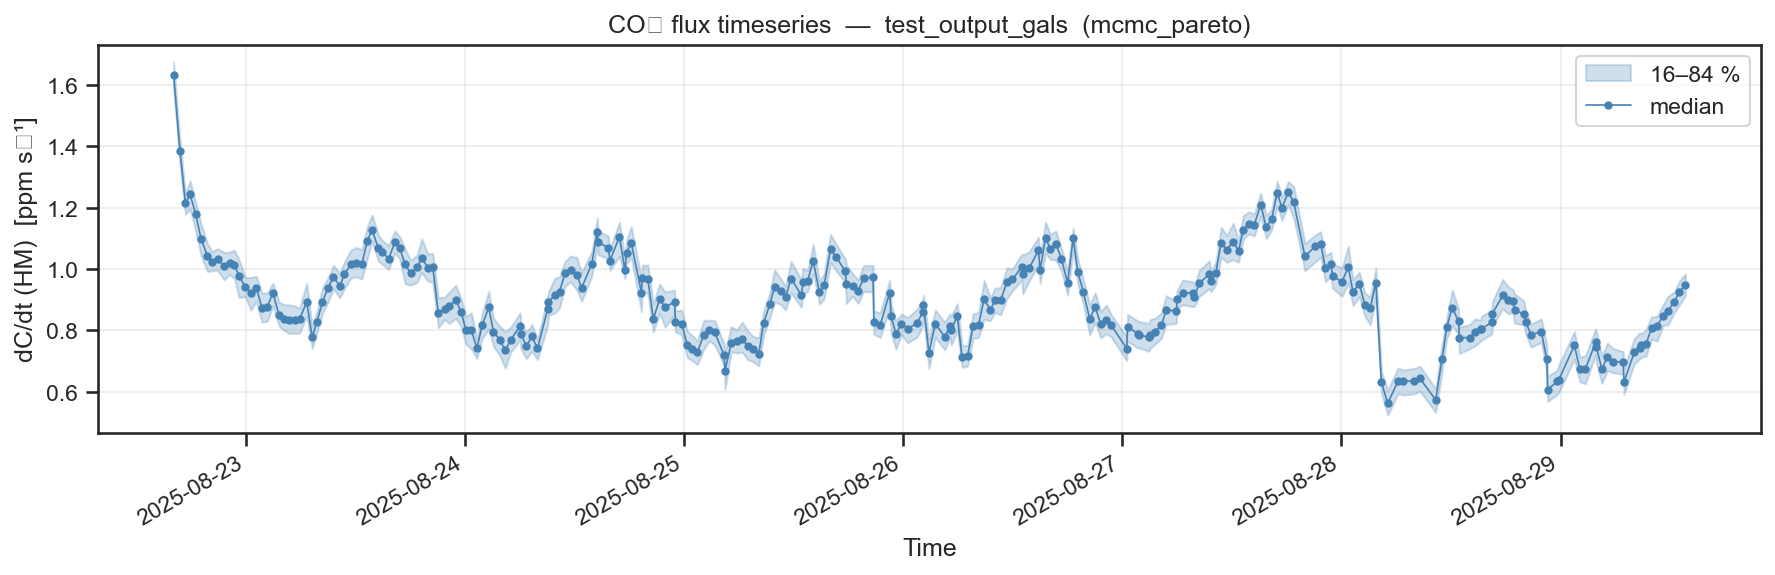

In [6]:
# ── Plot 1: dcdt timeseries with 16–84 % uncertainty band ──────────────────

fig, ax = plt.subplots(figsize=(12, 4), dpi=fig_dpi)

has_uncertainty = not (summary['dcdt_q16'] == summary['dcdt_q84']).all()
if has_uncertainty:
    ax.fill_between(summary.index, summary['dcdt_q16'], summary['dcdt_q84'],
                    color='steelblue', alpha=0.25, label='16–84 %')

ax.plot(summary.index, summary['dcdt_median'],
        color='steelblue', marker='o', ms=3, lw=0.8, label='median')

ax.set_xlabel('Time')
ax.set_ylabel('dC/dt (HM)  [ppm s⁻¹]')
ax.set_title(f'CO₂ flux timeseries  —  {data_path.name}  ({run_type})')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()

if fig_output_dir:
    pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
    fig.savefig(pathlib.Path(fig_output_dir) / 'dcdt_timeseries.png', dpi=fig_dpi)

plt.show()

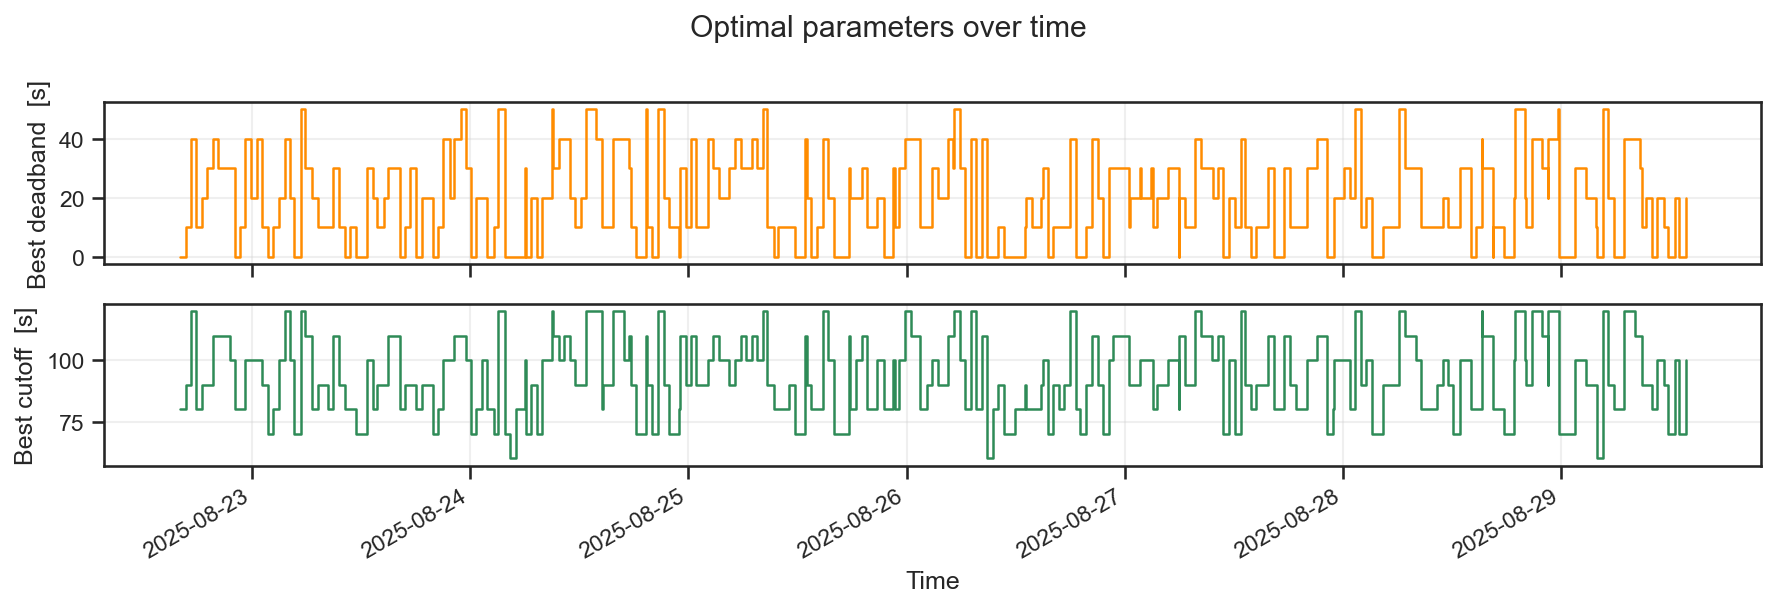

In [7]:
# ── Plot 2: best deadband & cutoff parameter timeseries ────────────────────

fig, axes = plt.subplots(2, 1, figsize=(12, 4), dpi=fig_dpi, sharex=True)

has_params = summary['best_deadband'].notna().any()

if has_params:
    axes[0].step(summary.index, summary['best_deadband'],
                 where='post', color='darkorange', lw=1.2)
    axes[0].set_ylabel('Best deadband  [s]')
    axes[0].grid(alpha=0.3)

    axes[1].step(summary.index, summary['best_cutoff'],
                 where='post', color='seagreen', lw=1.2)
    axes[1].set_ylabel('Best cutoff  [s]')
    axes[1].grid(alpha=0.3)
else:
    for ax in axes:
        ax.text(0.5, 0.5,
                'No parameter data\n(simple run with fixed cutoff/deadband)',
                ha='center', va='center', transform=ax.transAxes, color='gray')

axes[1].set_xlabel('Time')
fig.suptitle('Optimal parameters over time', y=1.01)
fig.autofmt_xdate()
plt.tight_layout()

if fig_output_dir:
    fig.savefig(pathlib.Path(fig_output_dir) / 'best_params_timeseries.png', dpi=fig_dpi)

plt.show()

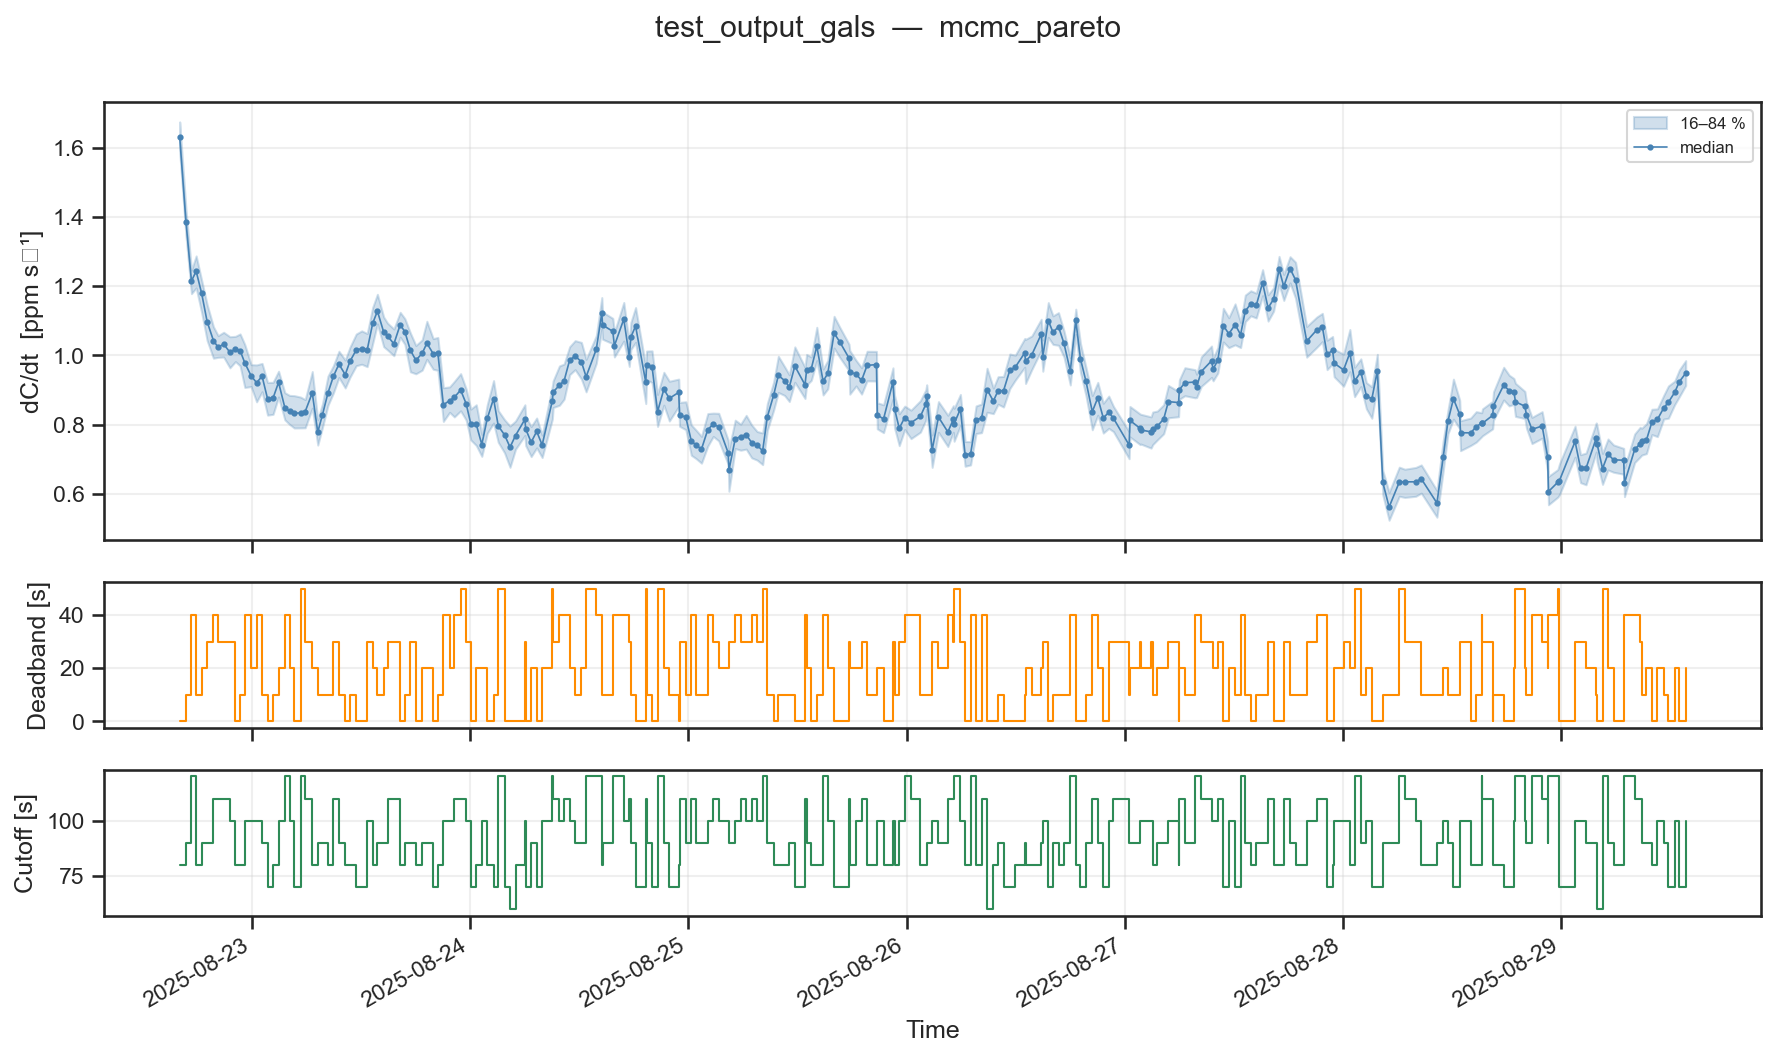

In [8]:
# ── Plot 3: 3-panel overview (flux + deadband + cutoff) ────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 7), dpi=fig_dpi, sharex=True,
                         gridspec_kw={'height_ratios': [3, 1, 1]})

# Panel 0 — dcdt
has_uncertainty = not (summary['dcdt_q16'] == summary['dcdt_q84']).all()
if has_uncertainty:
    axes[0].fill_between(summary.index, summary['dcdt_q16'], summary['dcdt_q84'],
                         color='steelblue', alpha=0.25, label='16–84 %')
axes[0].plot(summary.index, summary['dcdt_median'],
             color='steelblue', marker='o', ms=2, lw=0.8, label='median')
axes[0].set_ylabel('dC/dt  [ppm s⁻¹]')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(alpha=0.3)

# Panel 1 — deadband
if summary['best_deadband'].notna().any():
    axes[1].step(summary.index, summary['best_deadband'],
                 where='post', color='darkorange', lw=1.0)
axes[1].set_ylabel('Deadband [s]')
axes[1].grid(alpha=0.3)

# Panel 2 — cutoff
if summary['best_cutoff'].notna().any():
    axes[2].step(summary.index, summary['best_cutoff'],
                 where='post', color='seagreen', lw=1.0)
axes[2].set_ylabel('Cutoff [s]')
axes[2].set_xlabel('Time')
axes[2].grid(alpha=0.3)

fig.suptitle(f'{data_path.name}  —  {run_type}', y=1.005)
fig.autofmt_xdate()
plt.tight_layout()

if fig_output_dir:
    fig.savefig(pathlib.Path(fig_output_dir) / 'overview_3panel.png', dpi=fig_dpi)

plt.show()

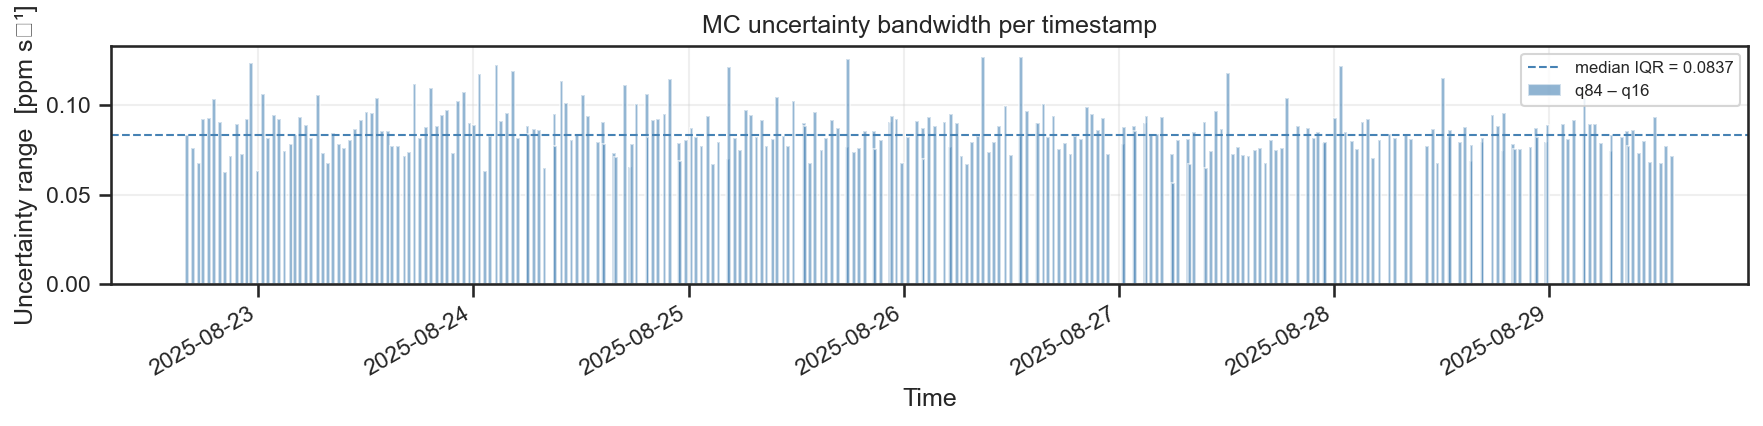

In [9]:
# ── Plot 4: MC uncertainty bandwidth (IQR) over time ──────────────────────

fig, ax = plt.subplots(figsize=(12, 3), dpi=fig_dpi)

iqr = summary['dcdt_q84'] - summary['dcdt_q16']
has_uncertainty = (iqr > 0).any()

if has_uncertainty:
    # bar width = 70 % of median gap between measurements
    gaps = np.diff(summary.index.asi8)
    bar_width_days = (np.median(gaps) / 1e9 / 86400) * 0.7 if len(gaps) > 0 else 0.003
    ax.bar(summary.index, iqr,
           width=bar_width_days,
           color='steelblue', alpha=0.6, label='q84 – q16')
    ax.axhline(iqr.median(), color='steelblue', lw=1, ls='--',
               label=f'median IQR = {iqr.median():.4f}')
    ax.set_ylabel('Uncertainty range  [ppm s⁻¹]')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No MC uncertainty available for this run_type',
            ha='center', va='center', transform=ax.transAxes, color='gray')

ax.set_xlabel('Time')
ax.set_title('MC uncertainty bandwidth per timestamp')
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()

if fig_output_dir:
    fig.savefig(pathlib.Path(fig_output_dir) / 'uncertainty_bandwidth.png', dpi=fig_dpi)

plt.show()

## Section 4 — Optional: MC sample distribution for a single timestamp

Only applicable when `run_type = 'mcmc_pareto'` (requires the `ds` xarray.Dataset with a `MC` dimension).

Set `dist_timestamp` in the Configuration cell, or leave it as `None` to auto-select the timestamp with the highest median flux.

In [10]:
# ── Resolve timestamp and extract MC samples ───────────────────────────────

if ds is None or 'MC' not in ds.dims:
    print("MC distribution plot requires run_type='mcmc_pareto' — skipping.")
else:
    if dist_timestamp is None:
        sel_time = summary['dcdt_median'].idxmax()
        print(f"Auto-selected timestamp (highest median dcdt): {sel_time}")
    else:
        sel_time = pd.Timestamp(dist_timestamp)
        print(f"User-selected timestamp: {sel_time}")

    hist_dcdt = ds['dcdt(HM)'].sel(time=sel_time, method='nearest')
    hist_vals = hist_dcdt.values
    hist_q16, hist_q84 = np.quantile(hist_vals, [0.16, 0.84])
    hist_med = np.median(hist_vals)

    sel_deadband = int(ds['best_deadband'].sel(time=sel_time, method='nearest').values)
    sel_cutoff   = int(ds['best_cutoff'].sel(time=sel_time, method='nearest').values)

    print(f"  median = {hist_med:.5f}  |  q16 = {hist_q16:.5f}  |  q84 = {hist_q84:.5f}")
    print(f"  n_MC = {len(hist_vals)}  |  best_deadband = {sel_deadband}  |  best_cutoff = {sel_cutoff}")

Auto-selected timestamp (highest median dcdt): 2025-08-22 16:04:00
  median = 1.63210  |  q16 = 1.59058  |  q84 = 1.67424
  n_MC = 4000  |  best_deadband = 0  |  best_cutoff = 80


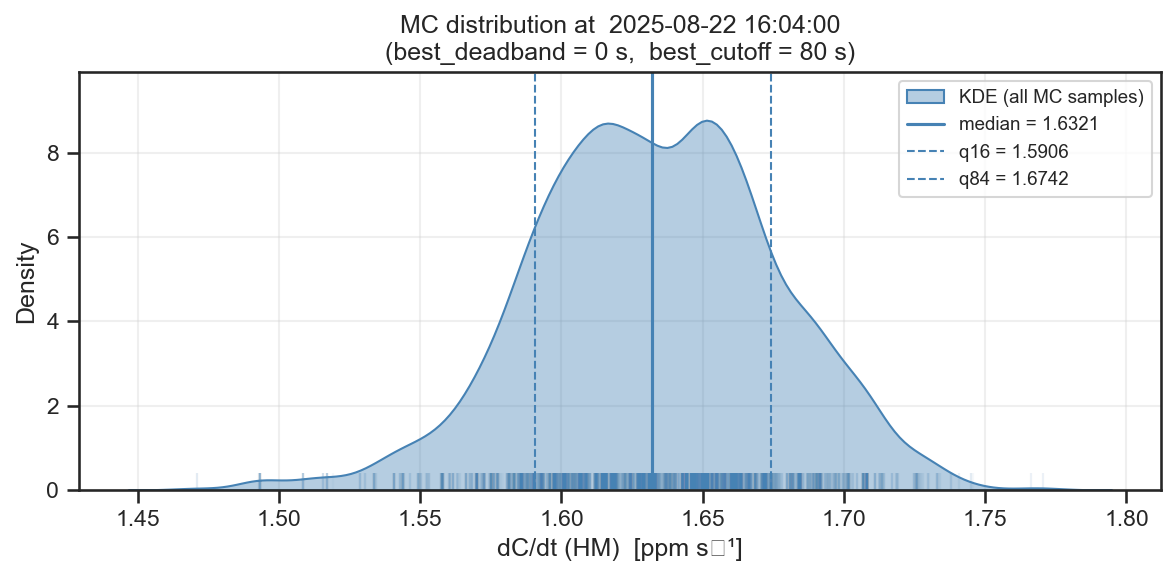

In [11]:
# ── KDE + rug plot of MC samples ───────────────────────────────────────────

if ds is None or 'MC' not in ds.dims:
    print("MC distribution plot requires run_type='mcmc_pareto' — skipping.")
else:
    fig, ax = plt.subplots(figsize=(8, 4), dpi=fig_dpi)

    sns.kdeplot(hist_vals, fill=True, color='steelblue', alpha=0.4,
                bw_adjust=1.0, ax=ax, label='KDE (all MC samples)')
    sns.rugplot(hist_vals, color='steelblue', alpha=0.05, height=0.04, ax=ax)

    ax.axvline(hist_med, color='steelblue', lw=1.5, ls='-',
               label=f'median = {hist_med:.4f}')
    ax.axvline(hist_q16, color='steelblue', lw=1.0, ls='--',
               label=f'q16 = {hist_q16:.4f}')
    ax.axvline(hist_q84, color='steelblue', lw=1.0, ls='--',
               label=f'q84 = {hist_q84:.4f}')

    ax.set_xlabel('dC/dt (HM)  [ppm s⁻¹]')
    ax.set_ylabel('Density')
    ax.set_title(f'MC distribution at  {sel_time}\n'
                 f'(best_deadband = {sel_deadband} s,  best_cutoff = {sel_cutoff} s)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    if fig_output_dir:
        fig.savefig(pathlib.Path(fig_output_dir) / 'mc_distribution.png', dpi=fig_dpi)

    plt.show()

## Section 5 — MCMC vs. fixed (cutoff, deadband) combinations

Overlays the MCMC median + 16–84 % uncertainty band with timeseries reconstructed
from the **simple** run for a few hand-picked `(cutoff, deadband)` pairs.
Lower subplots show the per-timestamp best parameters chosen by MCMC.

Requires both `*_bestPareto.nc` (already loaded as `summary` / `ds`) **and** the
matching simple `*.nc` files in the same `data_path`. Run with `run_type = 'mcmc_pareto'`.

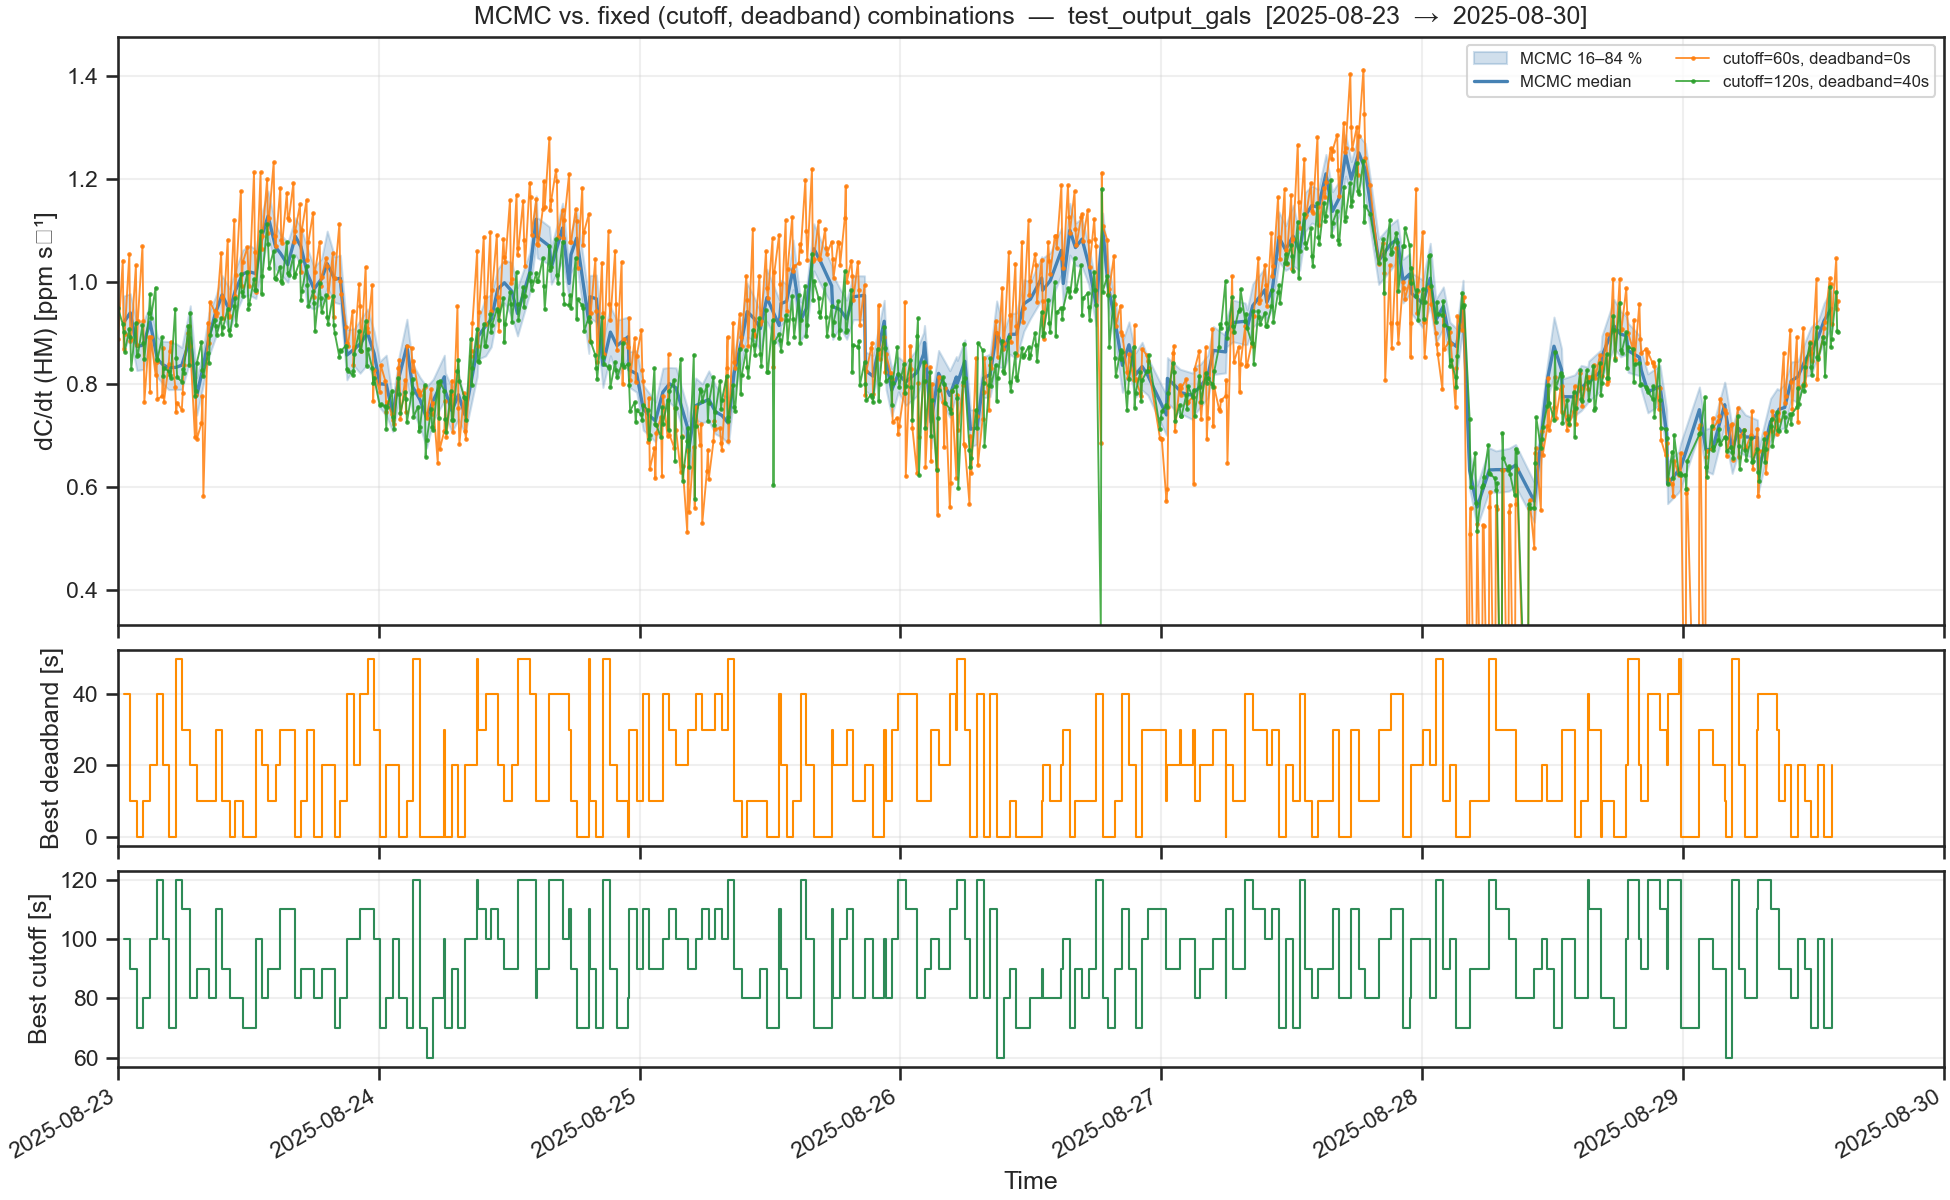

In [12]:
# ── Plot 5: MCMC band/median + fixed (cutoff, deadband) overlays ───────────
#
# Re-implementation that defends against the "Image size too large" error:
#   • disable the inline backend's bbox_inches='tight' (it walks ALL artist
#     extents, so a single ±inf or NaT value blows the figure to ~140k px),
#   • sanitise every plotted array (replace ±inf / NaN, drop bad timestamps),
#   • clamp the flux panel to the MCMC envelope.

# 1) Force the inline backend to use a fixed bbox for THIS notebook session.
try:
    get_ipython().run_line_magic(
        'config', "InlineBackend.print_figure_kwargs = {'bbox_inches': None}"
    )
except Exception:
    pass

# (cutoff [s], deadband [s]) pairs to overlay on top of the MCMC band.
comparison_combinations = [(60, 0), (120, 40)]

# Crop window for this plot only (independent of the notebook-wide
# date_start / date_end). ISO strings, inclusive — set either to None to
# leave that side of the window unbounded.
plot_start = '2025-08-23'   # e.g. '2026-04-03'
plot_end   = '2025-08-30'   # e.g. '2026-04-07'


def _clean_series(idx, values):
    """Return (idx, values) with NaT/non-finite rows removed."""
    idx  = pd.DatetimeIndex(idx)
    vals = np.asarray(values, dtype=float)
    mask = ~idx.isna() & np.isfinite(vals)
    return idx[mask], vals[mask]


def _crop(idx, values, start, end):
    """Apply [start, end] crop (inclusive). Either bound may be None."""
    idx = pd.DatetimeIndex(idx)
    mask = np.ones(len(idx), dtype=bool)
    if start is not None:
        mask &= idx >= pd.Timestamp(start)
    if end is not None:
        mask &= idx <= pd.Timestamp(end)
    return idx[mask], np.asarray(values)[mask]


if run_type != 'mcmc_pareto' or ds is None:
    print("Section 5 requires run_type='mcmc_pareto' — skipping.")
else:
    # ── Load matching simple .nc files (exclude bestPareto siblings) ────────
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    # Apply this-plot-only crop to the simple dataset as well.
    ds_simple = ds_simple.sel(time=slice(plot_start, plot_end))

    # ── Sanitise + crop the MCMC summary (dcdt_median / q16 / q84) ──────────
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (
        ~s_idx.isna()
        & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84)
    )
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]

    # Crop the MCMC arrays to [plot_start, plot_end].
    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot_start)
    if plot_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    if len(s_idx) == 0:
        raise ValueError(
            f"No MCMC data inside [{plot_start}, {plot_end}] — "
            f"available range: {summary.index.min()} → {summary.index.max()}"
        )

    # ── Build figure ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        3, 1, figsize=(13, 8), dpi=fig_dpi, sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    # Panel 0 — MCMC band + median + fixed-combo overlays
    ax = axes[0]
    ax.fill_between(s_idx, q16, q84, color='steelblue', alpha=0.25,
                    label='MCMC 16–84 %')
    ax.plot(s_idx, med, color='steelblue', lw=1.6, label='MCMC median')

    overlay_colors  = plt.get_cmap('tab10')
    avail_cutoffs   = set(np.atleast_1d(ds_simple['cutoff'].values).tolist())
    avail_deadbands = set(np.atleast_1d(ds_simple['deadband'].values).tolist())
    simple_time_raw = ds_simple['time'].values

    for i, (c, d) in enumerate(comparison_combinations):
        if c not in avail_cutoffs or d not in avail_deadbands:
            print(f"  ⚠  (cutoff={c}, deadband={d}) not in simple grid — skipping.")
            continue
        da = ds_simple['dcdt(HM)'].sel(cutoff=c, deadband=d)
        # The simple .nc files retain the MC sample dim — collapse to the
        # per-timestamp median so we get a 1-D series for plotting.
        if 'MC' in da.dims:
            da = da.median(dim='MC')
        flux_raw = da.values
        ts, flux = _clean_series(simple_time_raw, flux_raw)
        if len(ts) == 0:
            print(f"  ⚠  (cutoff={c}, deadband={d}) — all values non-finite, skipping.")
            continue
        ax.plot(ts, flux,
                color=overlay_colors((i + 1) % 10),
                lw=0.9, alpha=0.85, marker='.', ms=2.5,
                label=f'cutoff={c}s, deadband={d}s')

    # Clamp y-range to MCMC envelope (with margin) — robust to outliers.
    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.25 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot_start or '…'}  →  {plot_end or '…'}"
    ax.set_ylabel('dC/dt (HM) [ppm s⁻¹]')
    ax.set_title(
        f'MCMC vs. fixed (cutoff, deadband) combinations  —  '
        f'{data_path.name}  [{title_window}]'
    )
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(alpha=0.3)

    # Panel 1 — MCMC best deadband (cropped)
    db_idx, db_val = _clean_series(summary.index, summary['best_deadband'])
    db_idx, db_val = _crop(db_idx, db_val, plot_start, plot_end)
    axes[1].step(db_idx, db_val, where='post', color='darkorange', lw=1.0)
    axes[1].set_ylabel('Best deadband [s]')
    axes[1].grid(alpha=0.3)

    # Panel 2 — MCMC best cutoff (cropped)
    co_idx, co_val = _clean_series(summary.index, summary['best_cutoff'])
    co_idx, co_val = _crop(co_idx, co_val, plot_start, plot_end)
    axes[2].step(co_idx, co_val, where='post', color='seagreen', lw=1.0)
    axes[2].set_ylabel('Best cutoff [s]')
    axes[2].set_xlabel('Time')
    axes[2].grid(alpha=0.3)

    # Pin the shared x-axis to the requested window (avoids whitespace at edges
    # if a subplot has fewer points after cropping).
    if plot_start is not None or plot_end is not None:
        x_lo = pd.Timestamp(plot_start) if plot_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot_end)   if plot_end   is not None else s_idx.max()
        axes[0].set_xlim(x_lo, x_hi)

    for label in axes[2].get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_combinations.png',
            dpi=fig_dpi,  # explicit standard bbox — no 'tight'
        )

    plt.show()

## Section 6 — All (cutoff, deadband) combinations

Plots **every** `(cutoff, deadband)` combination from the simple dataset
(median over MC) on top of the MCMC band/median. Use `excluded_combinations`
to drop noisy/outlier pairs that you don't want on the chart.

Plotting 66 of 66 combinations (0 excluded).


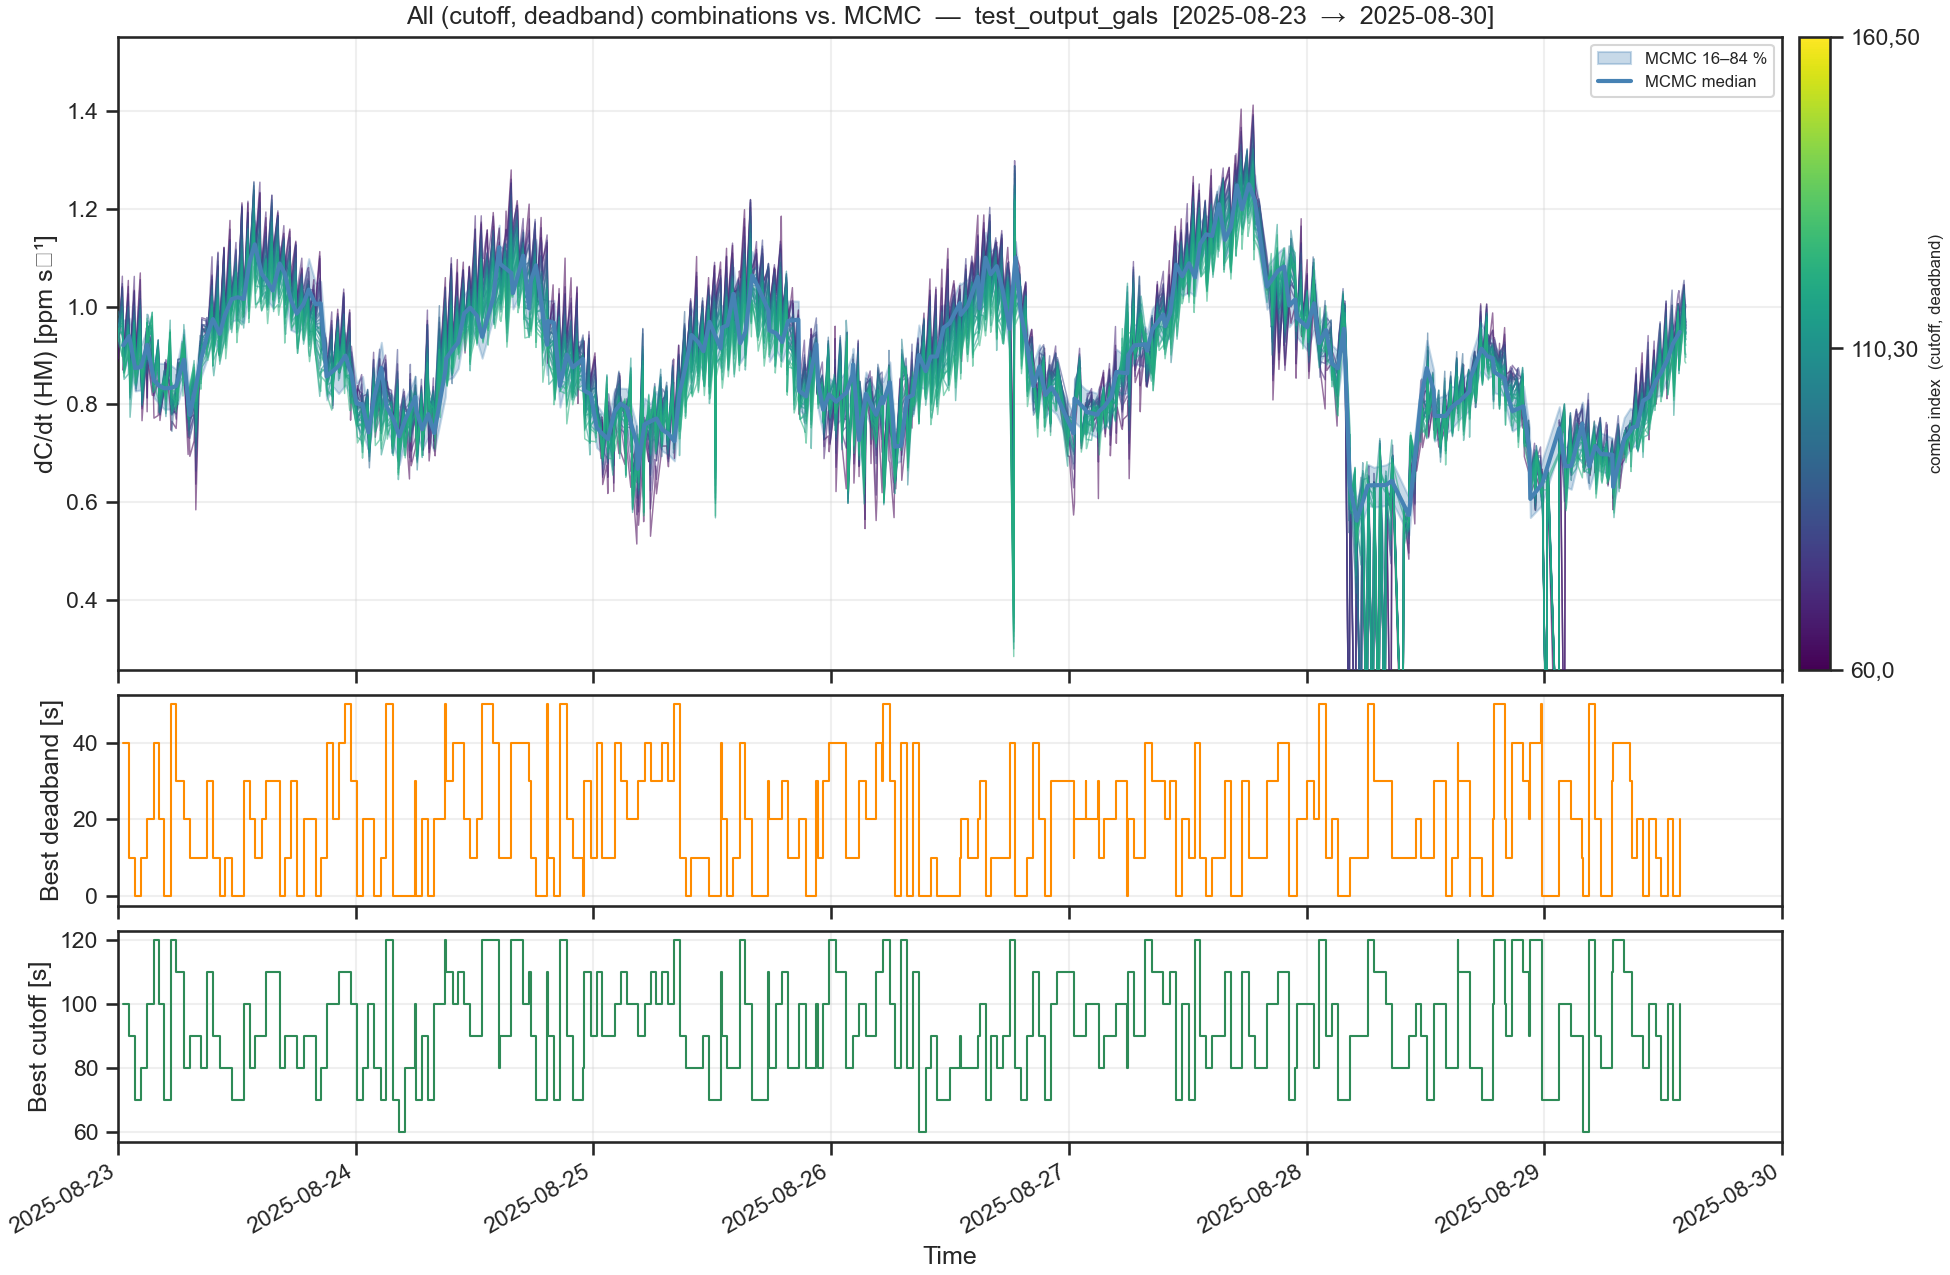

In [13]:
# ── Plot 6: every (cutoff, deadband) combination overlaid on MCMC band ─────

# Combinations to EXCLUDE from the plot. Each entry is (cutoff, deadband).
# Use this to drop pairs that are obviously noisy / poorly conditioned.
excluded_combinations = [
    # (60, 0),
    # (120, 60),
]

# Reuse the same crop window as Section 5 by default; override here if needed.
plot6_start = plot_start
plot6_end   = plot_end

# Style: alpha for the overlay lines, lower → more transparent so the MCMC
# band stays readable when many combinations are stacked.
overlay_alpha = 0.55
overlay_lw    = 0.7

if run_type != 'mcmc_pareto' or ds is None:
    print("Section 6 requires run_type='mcmc_pareto' — skipping.")
else:
    # Reload + crop the simple dataset (independent of Section 5 state).
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    ds_simple = ds_simple.sel(time=slice(plot6_start, plot6_end))

    # Sanitise + crop the MCMC summary.
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (~s_idx.isna()
             & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84))
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]
    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot6_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot6_start)
    if plot6_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot6_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    if len(s_idx) == 0:
        raise ValueError(
            f"No MCMC data inside [{plot6_start}, {plot6_end}] — "
            f"available range: {summary.index.min()} → {summary.index.max()}"
        )

    # Build the full grid of (cutoff, deadband) and apply the exclusion list.
    cutoffs   = np.atleast_1d(ds_simple['cutoff'].values).tolist()
    deadbands = np.atleast_1d(ds_simple['deadband'].values).tolist()
    excluded  = {tuple(p) for p in excluded_combinations}
    all_pairs = [(c, d) for c in cutoffs for d in deadbands
                 if (c, d) not in excluded]
    print(f"Plotting {len(all_pairs)} of {len(cutoffs) * len(deadbands)} combinations "
          f"({len(excluded)} excluded).")

    # Collapse MC dim once for the whole grid (much faster than per-pair).
    da_grid = ds_simple['dcdt(HM)']
    if 'MC' in da_grid.dims:
        da_grid = da_grid.median(dim='MC')

    fig, axes = plt.subplots(
        3, 1, figsize=(13, 8.5), dpi=fig_dpi, sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    # Panel 0 — MCMC band + median + every (filtered) combo overlay
    ax = axes[0]
    ax.fill_between(s_idx, q16, q84, color='steelblue', alpha=0.30,
                    label='MCMC 16–84 %', zorder=2)
    ax.plot(s_idx, med, color='steelblue', lw=2.0, label='MCMC median', zorder=4)

    cmap = plt.get_cmap('viridis')
    simple_time_raw = ds_simple['time'].values

    for k, (c, d) in enumerate(all_pairs):
        flux_raw = da_grid.sel(cutoff=c, deadband=d).values
        ts, flux = _clean_series(simple_time_raw, flux_raw)
        if len(ts) == 0:
            continue
        color = cmap(k / max(len(all_pairs) - 1, 1))
        ax.plot(ts, flux, color=color, lw=overlay_lw, alpha=overlay_alpha, zorder=3)

    # Build a discrete colorbar so the user can decode which line is which
    # without a 50-entry legend cluttering the plot.
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=0, vmax=max(len(all_pairs) - 1, 1)),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, fraction=0.025)
    cbar.set_label('combo index  (cutoff, deadband)', fontsize=8)
    # Tick at first/middle/last so the user can locate combos without spam.
    if len(all_pairs) > 1:
        idxs = [0, len(all_pairs) // 2, len(all_pairs) - 1]
        cbar.set_ticks(idxs)
        cbar.set_ticklabels([f'{all_pairs[i][0]},{all_pairs[i][1]}' for i in idxs])

    # Y-clamp to MCMC envelope ± 35 % so individual outlier curves can't
    # stretch the layout (same defense as Section 5).
    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.35 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot6_start or '…'}  →  {plot6_end or '…'}"
    ax.set_ylabel('dC/dt (HM) [ppm s⁻¹]')
    ax.set_title(
        f'All (cutoff, deadband) combinations vs. MCMC  —  '
        f'{data_path.name}  [{title_window}]'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # Panels 1 & 2 — best deadband / cutoff (same as Section 5)
    db_idx, db_val = _clean_series(summary.index, summary['best_deadband'])
    db_idx, db_val = _crop(db_idx, db_val, plot6_start, plot6_end)
    axes[1].step(db_idx, db_val, where='post', color='darkorange', lw=1.0)
    axes[1].set_ylabel('Best deadband [s]')
    axes[1].grid(alpha=0.3)

    co_idx, co_val = _clean_series(summary.index, summary['best_cutoff'])
    co_idx, co_val = _crop(co_idx, co_val, plot6_start, plot6_end)
    axes[2].step(co_idx, co_val, where='post', color='seagreen', lw=1.0)
    axes[2].set_ylabel('Best cutoff [s]')
    axes[2].set_xlabel('Time')
    axes[2].grid(alpha=0.3)

    if plot6_start is not None or plot6_end is not None:
        x_lo = pd.Timestamp(plot6_start) if plot6_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot6_end)   if plot6_end   is not None else s_idx.max()
        axes[0].set_xlim(x_lo, x_hi)

    for label in axes[2].get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_all_combinations.png',
            dpi=fig_dpi,
        )

    plt.show()

Simple dataset: 311 / 786 timestamps kept (target=0 days 00:25:00, tol=±0 days 00:05:00, anchor=first_obs)
MCMC summary:   105 / 253 timestamps kept
Plotting 66 of 66 combinations (0 excluded).


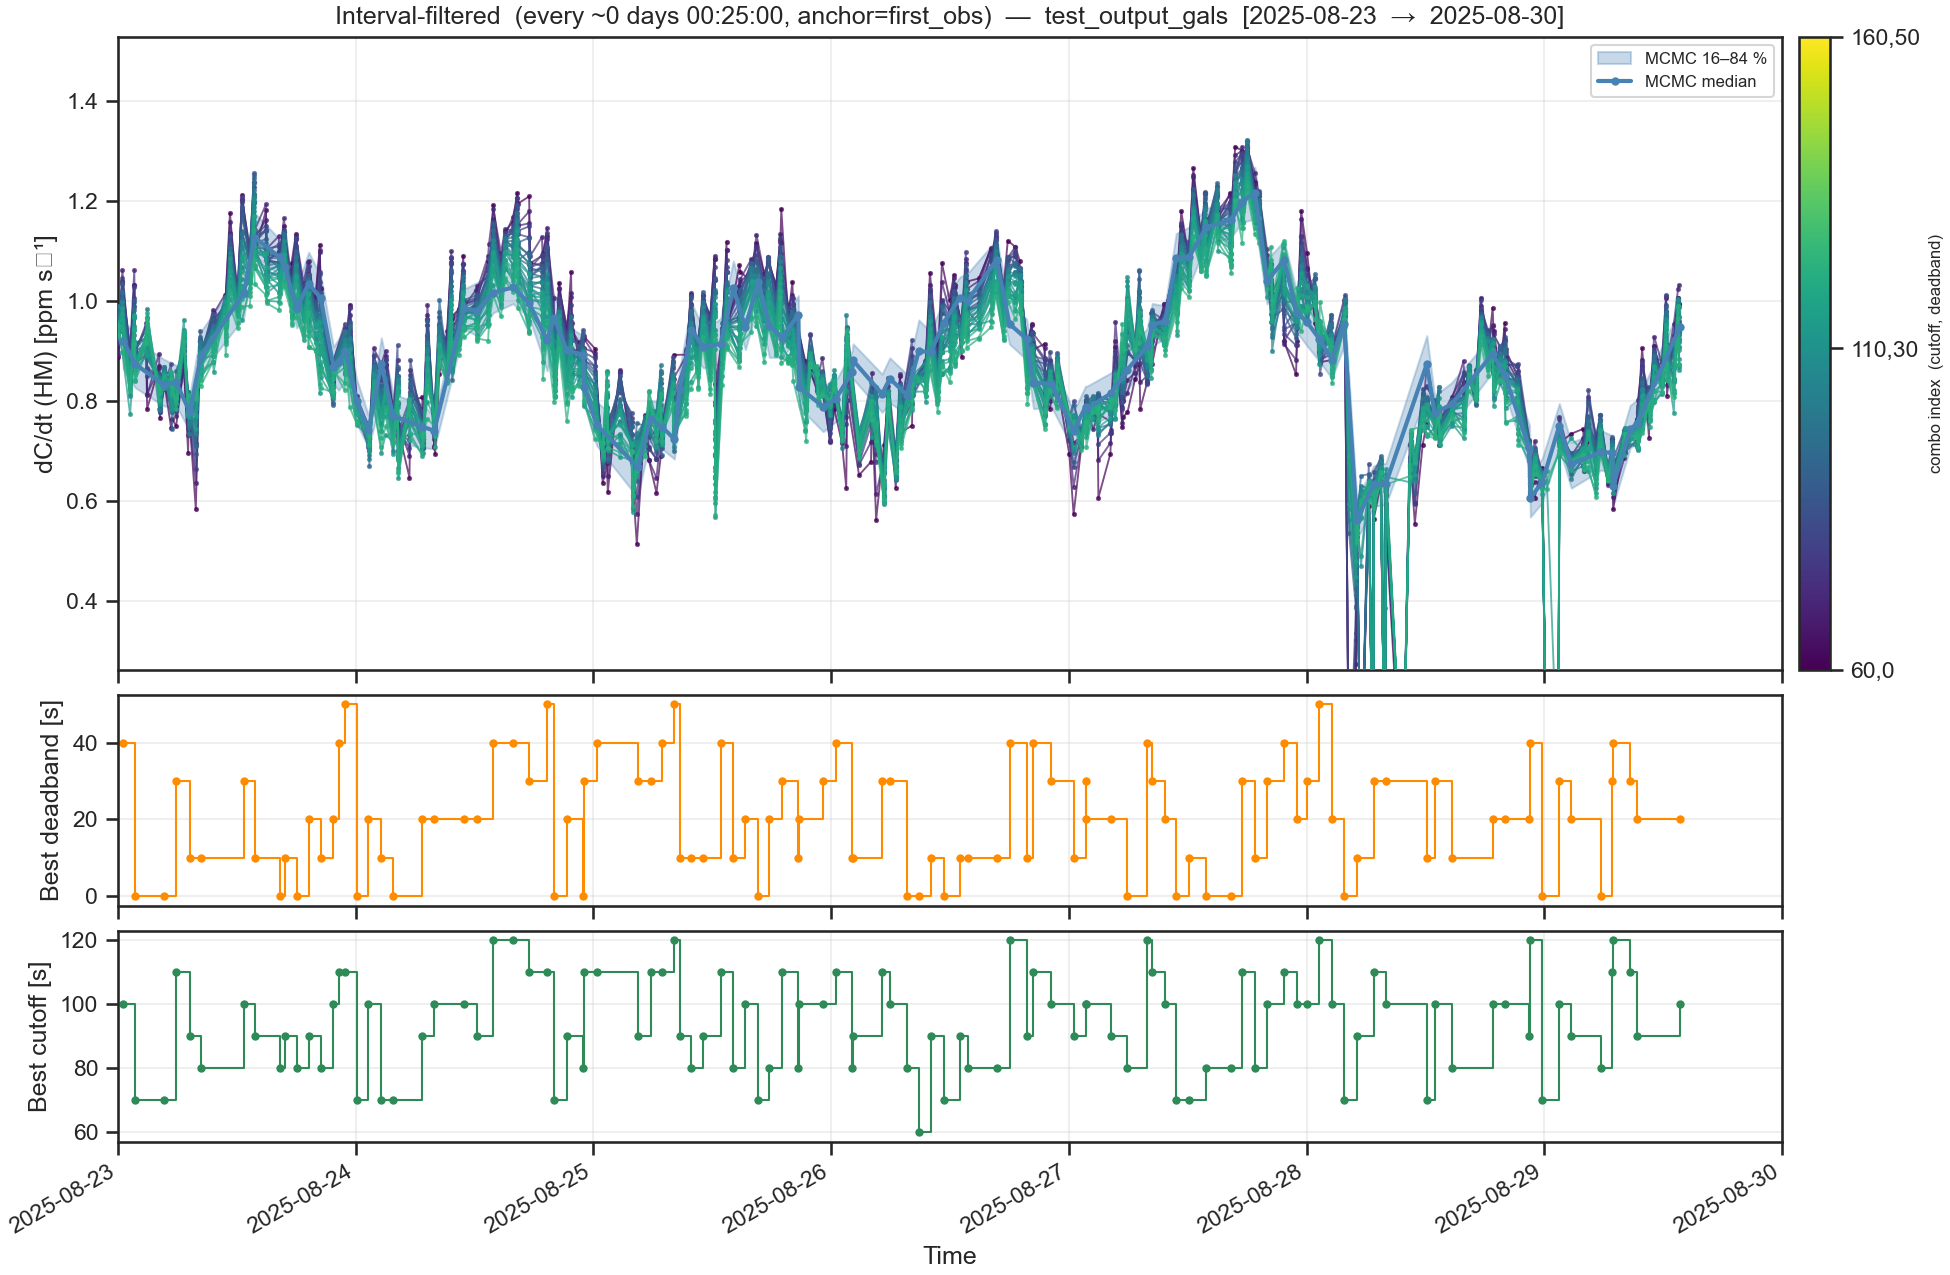

In [14]:
# ── Plot 7: same as Plot 6, but only every-N-minutes points kept ──────
#
# The raw data alternates between ~5 min and ~25 min spacing. To get a
# uniformly-sampled view, we keep only the measurements whose offset from
# the start of *that day* lands on a multiple of `target_interval`
# (within `interval_tolerance`).
#
# Examples:
#   target_interval = '30min'  → roughly one point every 30 min per day
#   target_interval = '1H'     → roughly one point per hour per day
#
# `day_start` controls what counts as the day's starting point:
#   'midnight'   → calendar day start (00:00 of each day)
#   'first_obs'  → first measurement of each day

target_interval    = pd.Timedelta('25min')
interval_tolerance = pd.Timedelta('5min')
day_start          = 'first_obs'   # 'midnight' or 'first_obs'

# Re-use the same crop window as the previous plot; override here if needed.
plot7_start = plot_start
plot7_end   = plot_end

overlay_alpha = 0.7
overlay_lw    = 0.9


def _interval_mask(idx, target, tol, mode):
    """Keep timestamps whose offset from day-start is ~k*target (±tol)."""
    idx = pd.DatetimeIndex(idx)
    if mode == 'midnight':
        day_origin = idx.normalize()
    elif mode == 'first_obs':
        day_origin = pd.DatetimeIndex(
            idx.to_series().groupby(idx.normalize()).transform('min').values
        )
    else:
        raise ValueError(f"day_start must be 'midnight' or 'first_obs', got {mode!r}")
    offset_s = (idx - day_origin).total_seconds()
    target_s = target.total_seconds()
    tol_s    = tol.total_seconds()
    mod      = offset_s % target_s
    return (mod <= tol_s) | (mod >= target_s - tol_s)


if run_type != 'mcmc_pareto' or ds is None:
    print("Section 7 requires run_type='mcmc_pareto' — skipping.")
else:
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    ds_simple = ds_simple.sel(time=slice(plot7_start, plot7_end))

    # ── Build the interval-spaced mask for the SIMPLE dataset ──────────
    simple_time_raw = pd.DatetimeIndex(ds_simple['time'].values)
    simple_mask = _interval_mask(
        simple_time_raw, target_interval, interval_tolerance, day_start
    )
    ds_simple = ds_simple.isel(time=simple_mask)
    print(f"Simple dataset: {simple_mask.sum()} / {len(simple_mask)} timestamps kept "
          f"(target={target_interval}, tol=±{interval_tolerance}, anchor={day_start})")

    # ── Sanitise + crop the MCMC summary, then apply the same mask ─────
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (~s_idx.isna()
             & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84))
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]

    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot7_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot7_start)
    if plot7_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot7_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    mcmc_mask = _interval_mask(s_idx, target_interval, interval_tolerance, day_start)
    s_idx, med, q16, q84 = s_idx[mcmc_mask], med[mcmc_mask], q16[mcmc_mask], q84[mcmc_mask]
    print(f"MCMC summary:   {mcmc_mask.sum()} / {len(mcmc_mask)} timestamps kept")

    if len(s_idx) == 0:
        raise ValueError(
            f"No MCMC data left after interval filter — relax target_interval "
            f"or increase interval_tolerance."
        )

    # ── Build figure (same layout as Section 6) ────────────────
    excluded = {tuple(p) for p in excluded_combinations}
    cutoffs   = np.atleast_1d(ds_simple['cutoff'].values).tolist()
    deadbands = np.atleast_1d(ds_simple['deadband'].values).tolist()
    all_pairs = [(c, d) for c in cutoffs for d in deadbands
                 if (c, d) not in excluded]
    print(f"Plotting {len(all_pairs)} of {len(cutoffs) * len(deadbands)} combinations "
          f"({len(excluded)} excluded).")

    da_grid = ds_simple['dcdt(HM)']
    if 'MC' in da_grid.dims:
        da_grid = da_grid.median(dim='MC')

    fig, axes = plt.subplots(
        3, 1, figsize=(13, 8.5), dpi=fig_dpi, sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    ax = axes[0]
    ax.fill_between(s_idx, q16, q84, color='steelblue', alpha=0.30,
                    label='MCMC 16–84 %', zorder=2)
    ax.plot(s_idx, med, color='steelblue', lw=2.0, marker='o', ms=3,
            label='MCMC median', zorder=4)

    cmap = plt.get_cmap('viridis')
    simple_time_kept = ds_simple['time'].values

    for k, (c, d) in enumerate(all_pairs):
        flux_raw = da_grid.sel(cutoff=c, deadband=d).values
        ts, flux = _clean_series(simple_time_kept, flux_raw)
        if len(ts) == 0:
            continue
        color = cmap(k / max(len(all_pairs) - 1, 1))
        ax.plot(ts, flux, color=color, lw=overlay_lw, alpha=overlay_alpha,
                marker='.', ms=3, zorder=3)

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=0, vmax=max(len(all_pairs) - 1, 1)),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, fraction=0.025)
    cbar.set_label('combo index  (cutoff, deadband)', fontsize=8)
    if len(all_pairs) > 1:
        idxs = [0, len(all_pairs) // 2, len(all_pairs) - 1]
        cbar.set_ticks(idxs)
        cbar.set_ticklabels([f'{all_pairs[i][0]},{all_pairs[i][1]}' for i in idxs])

    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.35 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot7_start or '…'}  →  {plot7_end or '…'}"
    ax.set_ylabel('dC/dt (HM) [ppm s⁻¹]')
    ax.set_title(
        f'Interval-filtered  (every ~{target_interval}, anchor={day_start})  '
        f'—  {data_path.name}  [{title_window}]'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    db_idx, db_val = _clean_series(summary.index, summary['best_deadband'])
    db_idx, db_val = _crop(db_idx, db_val, plot7_start, plot7_end)
    db_keep = _interval_mask(db_idx, target_interval, interval_tolerance, day_start)
    axes[1].step(db_idx[db_keep], np.asarray(db_val)[db_keep],
                 where='post', color='darkorange', lw=1.0, marker='o', ms=3)
    axes[1].set_ylabel('Best deadband [s]')
    axes[1].grid(alpha=0.3)

    co_idx, co_val = _clean_series(summary.index, summary['best_cutoff'])
    co_idx, co_val = _crop(co_idx, co_val, plot7_start, plot7_end)
    co_keep = _interval_mask(co_idx, target_interval, interval_tolerance, day_start)
    axes[2].step(co_idx[co_keep], np.asarray(co_val)[co_keep],
                 where='post', color='seagreen', lw=1.0, marker='o', ms=3)
    axes[2].set_ylabel('Best cutoff [s]')
    axes[2].set_xlabel('Time')
    axes[2].grid(alpha=0.3)

    if plot7_start is not None or plot7_end is not None:
        x_lo = pd.Timestamp(plot7_start) if plot7_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot7_end)   if plot7_end   is not None else s_idx.max()
        axes[0].set_xlim(x_lo, x_hi)

    for label in axes[2].get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_all_combinations_interval.png',
            dpi=fig_dpi,
        )

    plt.show()


MCMC summary:   145 / 253 kept (min_gap=0 days 00:40:00, max_gap=0 days 00:50:00, restart=True)
Simple dataset: matched 145 / 145 MCMC timestamps (±1 min tolerance)
Plotting 66 of 66 combinations (0 excluded).


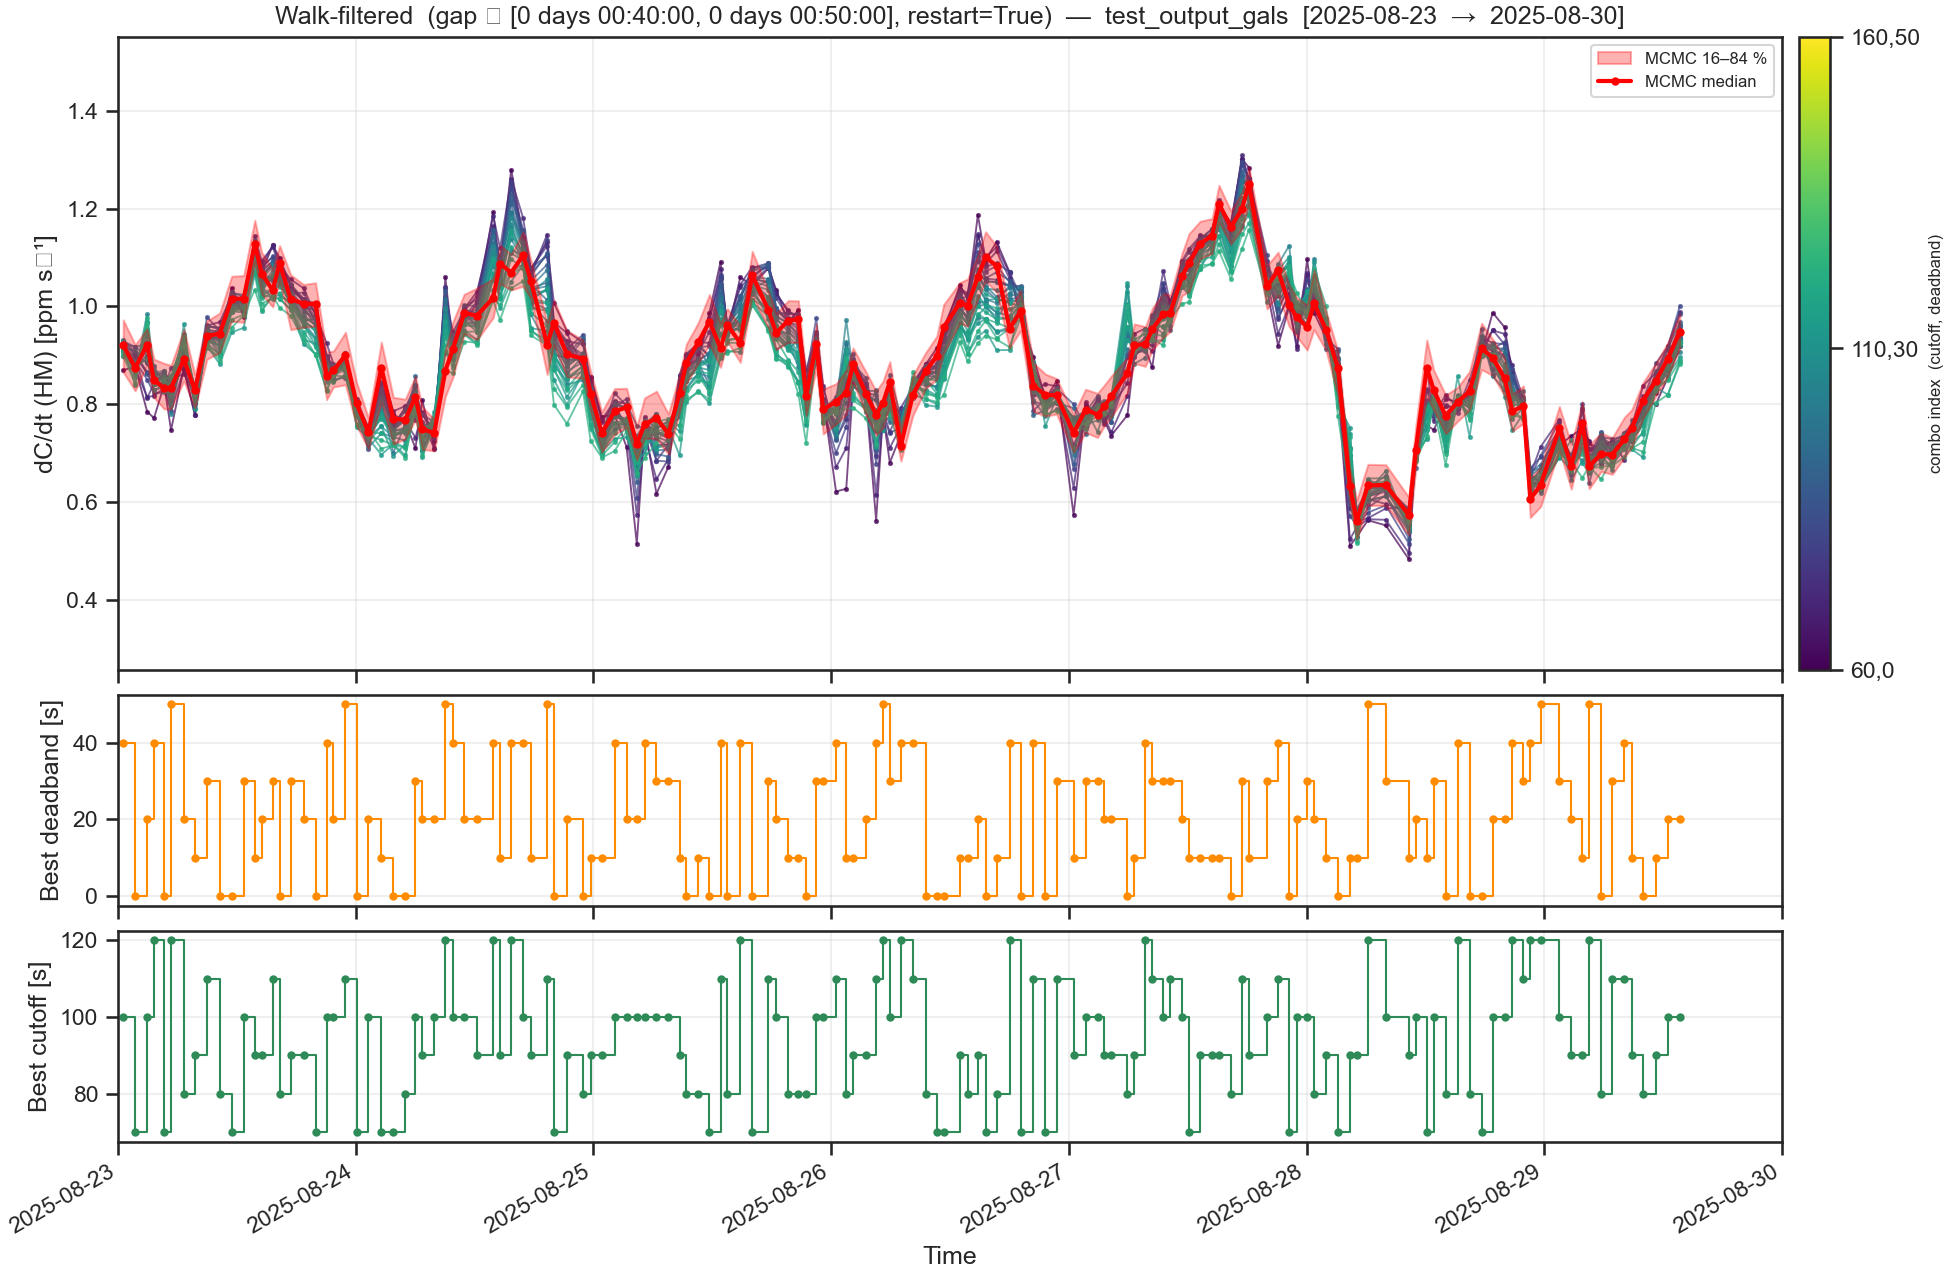

In [15]:
# ── Plot 8: walk-filter — keep next point only if gap ∈ [min_gap, max_gap] ──
#
# Goal: produce a chain of measurements with a *consistent* spacing between
# consecutive plotted points, without needing them to align on the day-start
# grid (unlike Plot 7).
#
# Algorithm (greedy walk through the sorted timeseries):
#   • Keep the first point.
#   • For each subsequent point, look at the gap to the last KEPT point.
#       – gap < min_gap   → skip (too close, wait for the next one).
#       – gap ∈ [min, max]→ keep, advance the "last kept" anchor.
#       – gap > max_gap   → keep but treat as a new chain start
#                           (so we recover after long measurement gaps
#                           instead of dropping the rest of the day).
#
# Set `restart_on_large_gap = False` to instead skip oversized jumps
# (will discard everything after the first long gap until the next point
# that happens to land back in range — rarely what you want).

min_gap = pd.Timedelta('40min')
max_gap = pd.Timedelta('50min')
restart_on_large_gap = True

# Crop window (independent of the other plots; defaults to Section 5's).
plot8_start = plot_start
plot8_end   = plot_end

overlay_alpha = 0.7
overlay_lw    = 0.9


def _walk_mask(idx, min_dt, max_dt, restart):
    """Greedy walk: keep points whose gap from the last kept point ∈ [min, max].

    Long gaps either start a new chain (restart=True) or are skipped
    (restart=False).
    """
    idx = pd.DatetimeIndex(idx)
    n = len(idx)
    keep = np.zeros(n, dtype=bool)
    if n == 0:
        return keep
    keep[0] = True
    last = idx[0]
    for i in range(1, n):
        dt = idx[i] - last
        if dt < min_dt:
            continue
        if dt > max_dt:
            if restart:
                keep[i] = True
                last = idx[i]
            # else: skip — wait for a point that lands back in range
            continue
        keep[i] = True
        last = idx[i]
    return keep


if run_type != 'mcmc_pareto' or ds is None:
    print("Section 8 requires run_type='mcmc_pareto' — skipping.")
else:
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    ds_simple = ds_simple.sel(time=slice(plot8_start, plot8_end))

    # ── Sanitise + crop the MCMC summary ──────────────────────────────────
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (~s_idx.isna()
             & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84))
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]
    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot8_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot8_start)
    if plot8_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot8_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    # ── Run the walk on the MCMC index — that's our anchor timegrid ───────
    mcmc_keep = _walk_mask(s_idx, min_gap, max_gap, restart_on_large_gap)
    s_idx, med, q16, q84 = s_idx[mcmc_keep], med[mcmc_keep], q16[mcmc_keep], q84[mcmc_keep]
    print(f"MCMC summary:   {mcmc_keep.sum()} / {len(mcmc_keep)} kept "
          f"(min_gap={min_gap}, max_gap={max_gap}, restart={restart_on_large_gap})")

    if len(s_idx) == 0:
        raise ValueError(
            "No MCMC points left after walk filter — widen [min_gap, max_gap]."
        )

    # Sync the simple dataset to the same kept timestamps (nearest match).
    # This guarantees the colored combo lines plot at the same x-positions
    # as the MCMC band/median.
    sel_times = xr.DataArray(s_idx.values, dims='time')
    ds_simple_kept = ds_simple.reindex(time=sel_times, method='nearest',
                                       tolerance=pd.Timedelta('1min'))
    n_matched = int(ds_simple_kept['time'].notnull().sum())
    print(f"Simple dataset: matched {n_matched} / {len(s_idx)} MCMC timestamps "
          f"(±1 min tolerance)")

    # ── Build figure (same layout as Sections 6 / 7) ──────────────────────
    excluded = {tuple(p) for p in excluded_combinations}
    cutoffs   = np.atleast_1d(ds_simple_kept['cutoff'].values).tolist()
    deadbands = np.atleast_1d(ds_simple_kept['deadband'].values).tolist()
    all_pairs = [(c, d) for c in cutoffs for d in deadbands
                 if (c, d) not in excluded]
    print(f"Plotting {len(all_pairs)} of {len(cutoffs) * len(deadbands)} combinations "
          f"({len(excluded)} excluded).")

    da_grid = ds_simple_kept['dcdt(HM)']
    if 'MC' in da_grid.dims:
        da_grid = da_grid.median(dim='MC')

    fig, axes = plt.subplots(
        3, 1, figsize=(13, 8.5), dpi=fig_dpi, sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    ax = axes[0]
    ax.fill_between(s_idx, q16, q84, color='red', alpha=0.30,
                    label='MCMC 16–84 %', zorder=20)
    ax.plot(s_idx, med, color='red', lw=2.0, marker='o', ms=3,
            label='MCMC median', zorder=20)

    cmap = plt.get_cmap('viridis')
    simple_time_kept = ds_simple_kept['time'].values

    for k, (c, d) in enumerate(all_pairs):
        flux_raw = da_grid.sel(cutoff=c, deadband=d).values
        ts, flux = _clean_series(simple_time_kept, flux_raw)
        if len(ts) == 0:
            continue
        color = cmap(k / max(len(all_pairs) - 1, 1))
        ax.plot(ts, flux, color=color, lw=overlay_lw, alpha=overlay_alpha,
                marker='.', ms=3, zorder=3)

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=0, vmax=max(len(all_pairs) - 1, 1)),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01, fraction=0.025)
    cbar.set_label('combo index  (cutoff, deadband)', fontsize=8)
    if len(all_pairs) > 1:
        idxs = [0, len(all_pairs) // 2, len(all_pairs) - 1]
        cbar.set_ticks(idxs)
        cbar.set_ticklabels([f'{all_pairs[i][0]},{all_pairs[i][1]}' for i in idxs])

    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.35 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot8_start or '…'}  →  {plot8_end or '…'}"
    ax.set_ylabel('dC/dt (HM) [ppm s⁻¹]')
    ax.set_title(
        f'Walk-filtered  (gap ∈ [{min_gap}, {max_gap}], restart={restart_on_large_gap})  '
        f'—  {data_path.name}  [{title_window}]'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    db_idx, db_val = _clean_series(summary.index, summary['best_deadband'])
    db_idx, db_val = _crop(db_idx, db_val, plot8_start, plot8_end)
    db_keep = _walk_mask(db_idx, min_gap, max_gap, restart_on_large_gap)
    axes[1].step(db_idx[db_keep], np.asarray(db_val)[db_keep],
                 where='post', color='darkorange', lw=1.0, marker='o', ms=3)
    axes[1].set_ylabel('Best deadband [s]')
    axes[1].grid(alpha=0.3)

    co_idx, co_val = _clean_series(summary.index, summary['best_cutoff'])
    co_idx, co_val = _crop(co_idx, co_val, plot8_start, plot8_end)
    co_keep = _walk_mask(co_idx, min_gap, max_gap, restart_on_large_gap)
    axes[2].step(co_idx[co_keep], np.asarray(co_val)[co_keep],
                 where='post', color='seagreen', lw=1.0, marker='o', ms=3)
    axes[2].set_ylabel('Best cutoff [s]')
    axes[2].set_xlabel('Time')
    axes[2].grid(alpha=0.3)

    if plot8_start is not None or plot8_end is not None:
        x_lo = pd.Timestamp(plot8_start) if plot8_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot8_end)   if plot8_end   is not None else s_idx.max()
        axes[0].set_xlim(x_lo, x_hi)

    for label in axes[2].get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_all_combinations_walk.png',
            dpi=fig_dpi,
        )

    plt.show()


In [16]:
import datetime as dt

MCMC summary:   127 / 253 kept (min_gap=0 days 00:45:00, max_gap=0 days 00:55:00, restart=True)
Simple dataset: matched 127 / 127 MCMC timestamps (±1 min tolerance)
Plotting 2 of 2 requested pairs.


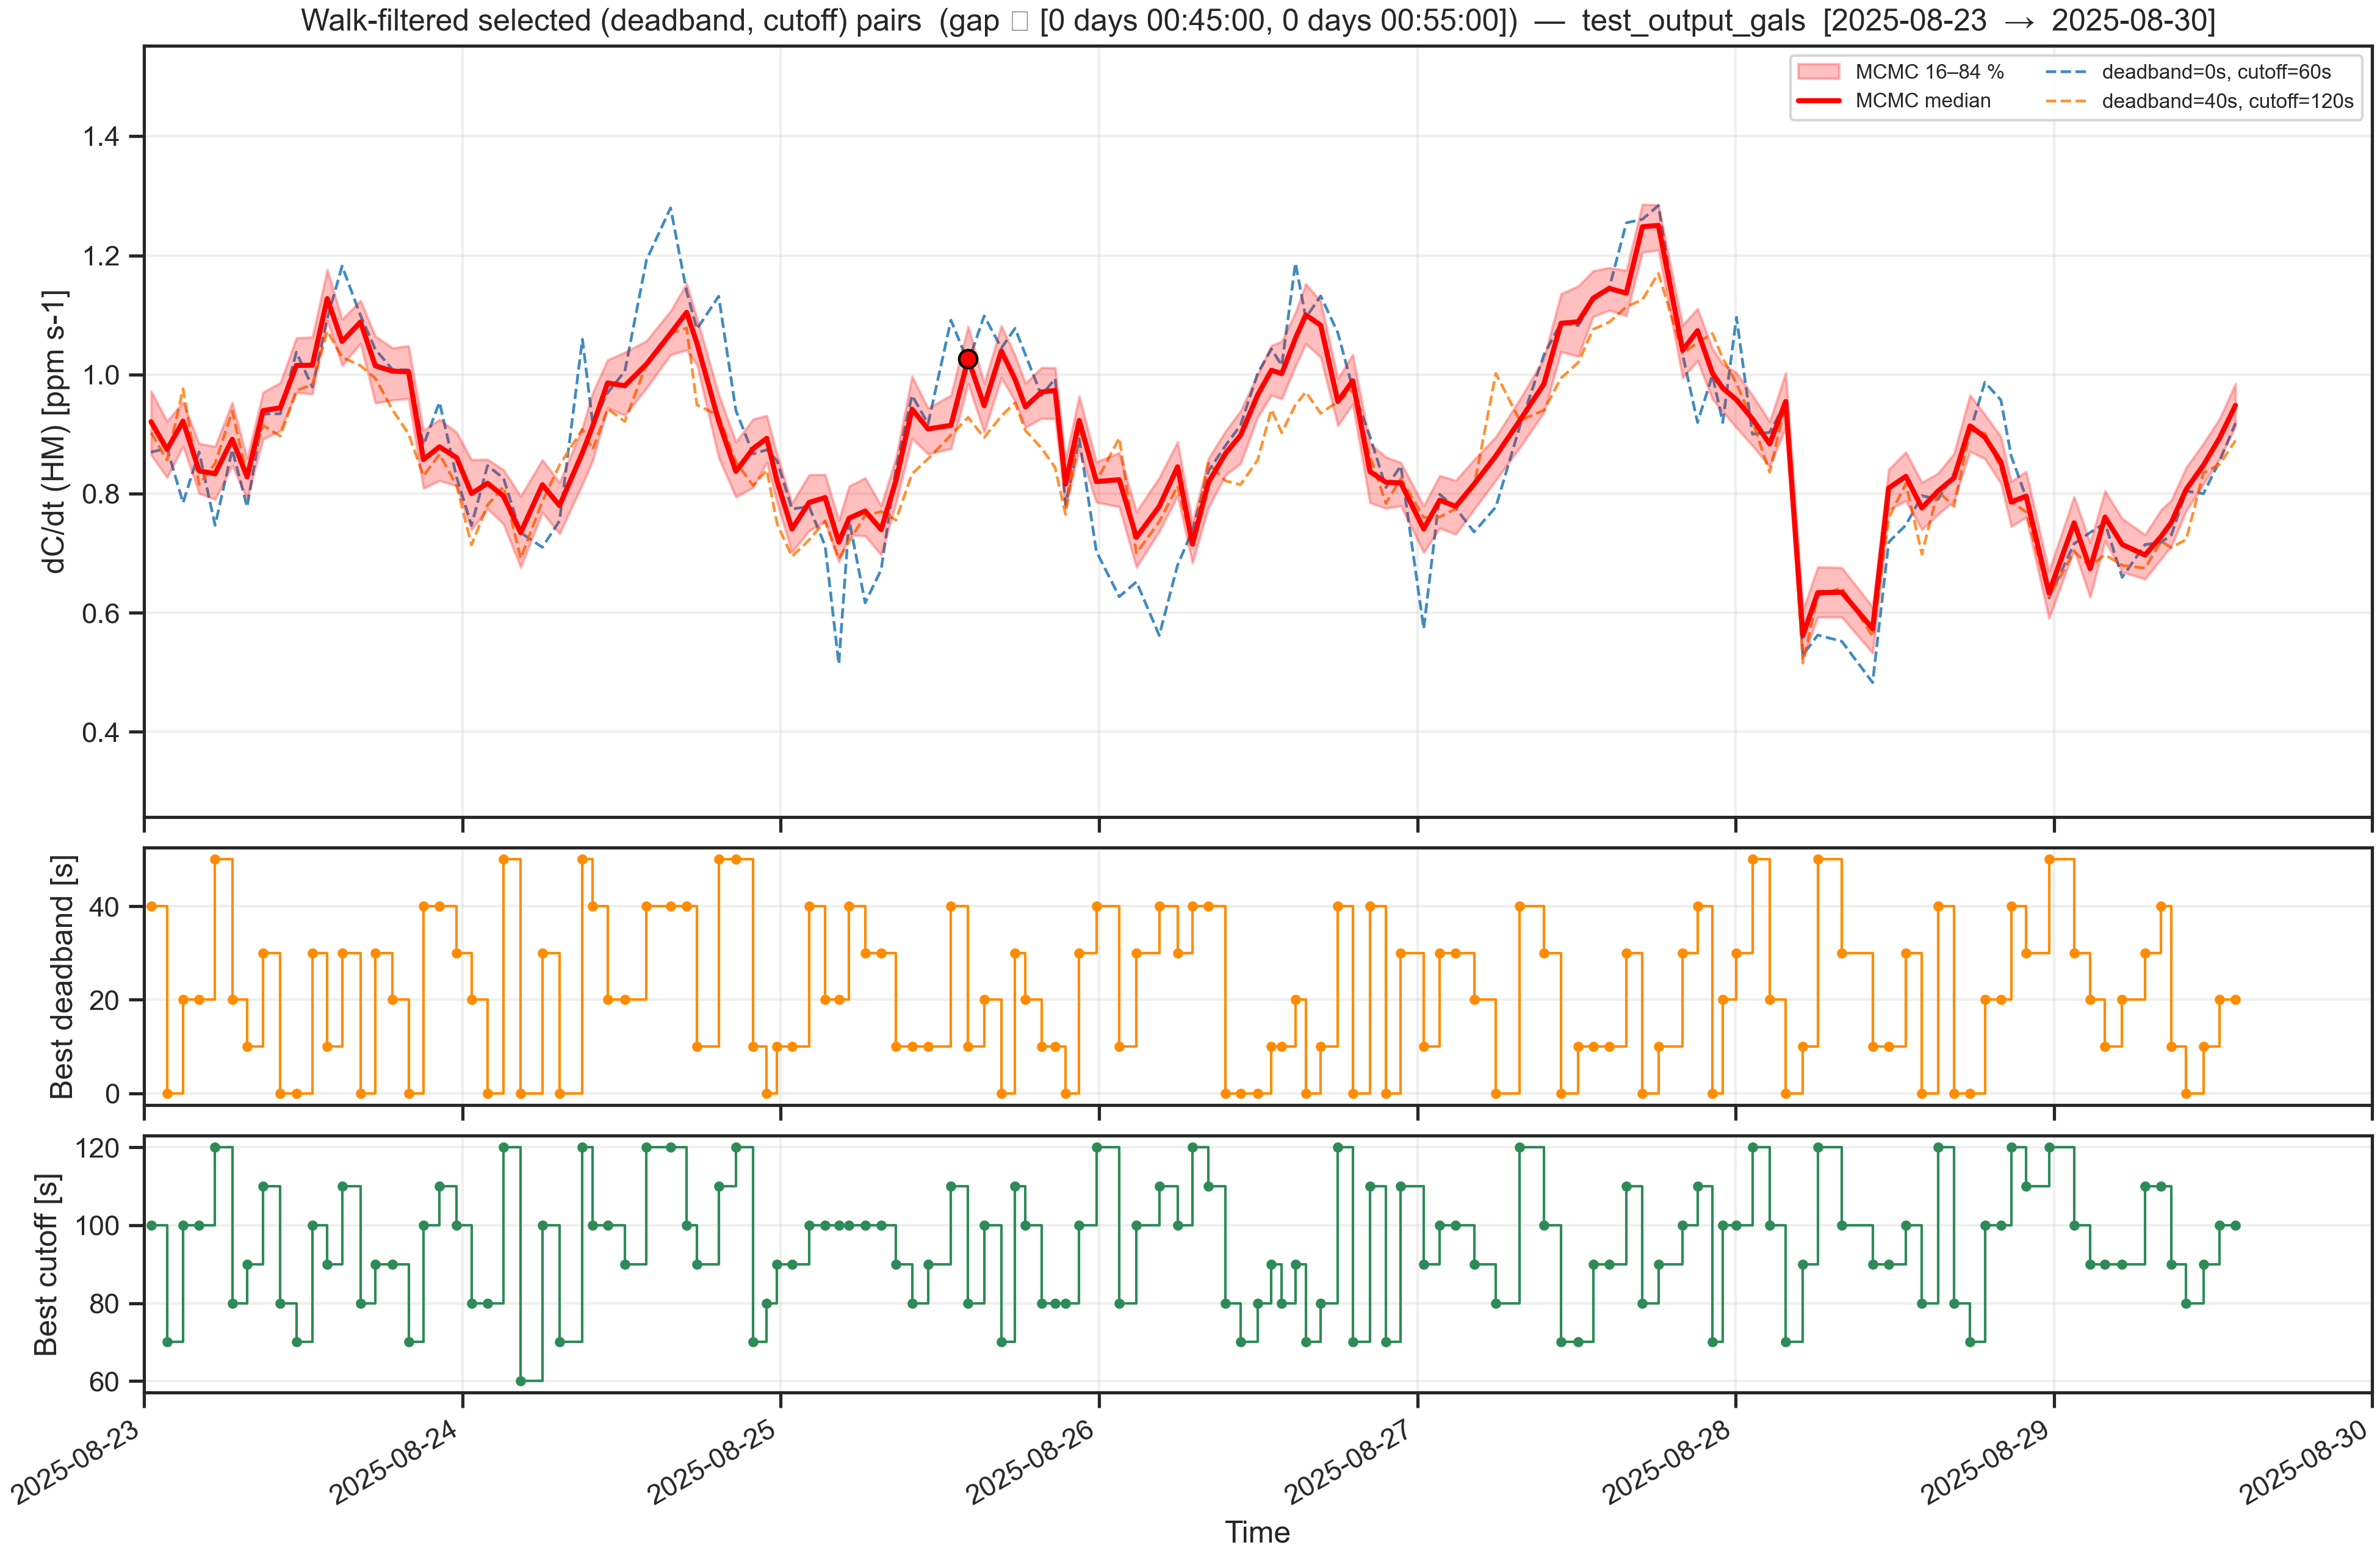

In [17]:
# ── Plot 9: walk-filter — only a hand-picked list of (deadband, cutoff) ─────
#
# Same walk-filter logic as Plot 8, but instead of plotting every
# (cutoff, deadband) combination from the simple grid we only plot the pairs
# listed in `selected_combinations` below. Each entry is (deadband, cutoff).

# (deadband [s], cutoff [s]) pairs to overlay on top of the MCMC band.
selected_combinations = [
    (0, 60),
    # (20, 90),
    (40, 120),
]

min_gap = pd.Timedelta('45min')
max_gap = pd.Timedelta('55min')
restart_on_large_gap = True

# Crop window (independent of the other plots; defaults to Section 5's).
plot9_start = plot_start
plot9_end   = plot_end

overlay_alpha = 0.85
overlay_lw    = 1.1


if run_type != 'mcmc_pareto' or ds is None:
    print("Section 9 requires run_type='mcmc_pareto' — skipping.")
else:
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    ds_simple = ds_simple.sel(time=slice(plot9_start, plot9_end))

    # ── Sanitise + crop the MCMC summary ──────────────────────────────────
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (~s_idx.isna()
             & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84))
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]
    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot9_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot9_start)
    if plot9_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot9_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    # Walk-filter the MCMC index.
    mcmc_keep = _walk_mask(s_idx, min_gap, max_gap, restart_on_large_gap)
    s_idx, med, q16, q84 = s_idx[mcmc_keep], med[mcmc_keep], q16[mcmc_keep], q84[mcmc_keep]
    print(f"MCMC summary:   {mcmc_keep.sum()} / {len(mcmc_keep)} kept "
          f"(min_gap={min_gap}, max_gap={max_gap}, restart={restart_on_large_gap})")

    if len(s_idx) == 0:
        raise ValueError(
            "No MCMC points left after walk filter — widen [min_gap, max_gap]."
        )

    # Sync the simple dataset to the same kept timestamps.
    sel_times = xr.DataArray(s_idx.values, dims='time')
    ds_simple_kept = ds_simple.reindex(time=sel_times, method='nearest',
                                       tolerance=pd.Timedelta('1min'))
    n_matched = int(ds_simple_kept['time'].notnull().sum())
    print(f"Simple dataset: matched {n_matched} / {len(s_idx)} MCMC timestamps "
          f"(±1 min tolerance)")

    # Validate the requested combinations against the simple grid.
    avail_cutoffs   = set(np.atleast_1d(ds_simple_kept['cutoff'].values).tolist())
    avail_deadbands = set(np.atleast_1d(ds_simple_kept['deadband'].values).tolist())
    valid_pairs = []
    for (d, c) in selected_combinations:
        if c not in avail_cutoffs or d not in avail_deadbands:
            print(f"  ⚠  (deadband={d}, cutoff={c}) not in simple grid — skipping.")
            continue
        valid_pairs.append((d, c))
    print(f"Plotting {len(valid_pairs)} of {len(selected_combinations)} requested pairs.")

    da_grid = ds_simple_kept['dcdt(HM)']
    if 'MC' in da_grid.dims:
        da_grid = da_grid.median(dim='MC')

    fig, axes = plt.subplots(
        3, 1, figsize=(13, 8.5), dpi=300, sharex=True,
        gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    ax = axes[0]
    ax.fill_between(s_idx, q16, q84, color='red', alpha=0.25,
                    label='MCMC 16–84 %', zorder=20)
    ax.plot(s_idx, med, color='red', lw=2.0,  ms=3,
            label='MCMC median', zorder=20)
    
    ax.scatter(s_idx[50], med[50], color='red', s=50, zorder=25, edgecolors='black', linewidths=1)

    overlay_colors = plt.get_cmap('tab10')
    simple_time_kept = ds_simple_kept['time'].values

    for k, (d, c) in enumerate(valid_pairs):
        flux_raw = da_grid.sel(cutoff=c, deadband=d).values
        ts, flux = _clean_series(simple_time_kept, flux_raw)
        if len(ts) == 0:
            print(f"  ⚠  (deadband={d}, cutoff={c}) — all values non-finite, skipping.")
            continue
        ax.plot(ts, flux,
                color=overlay_colors(k % 10),
                lw=overlay_lw, alpha=overlay_alpha, linestyle='--',
                ms=4, zorder=3,
                label=f'deadband={d}s, cutoff={c}s')

    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.35 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot9_start or '…'}  →  {plot9_end or '…'}"
    ax.set_ylabel('dC/dt (HM) [ppm s-1]')
    ax.set_title(
        f'Walk-filtered selected (deadband, cutoff) pairs  '
        f'(gap ∈ [{min_gap}, {max_gap}])  —  {data_path.name}  [{title_window}]'
    )
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(alpha=0.3)

    db_idx, db_val = _clean_series(summary.index, summary['best_deadband'])
    db_idx, db_val = _crop(db_idx, db_val, plot9_start, plot9_end)
    db_keep = _walk_mask(db_idx, min_gap, max_gap, restart_on_large_gap)
    axes[1].step(db_idx[db_keep], np.asarray(db_val)[db_keep],
                 where='post', color='darkorange', lw=1.0, marker='o', ms=3)
    axes[1].set_ylabel('Best deadband [s]')
    axes[1].grid(alpha=0.3)

    co_idx, co_val = _clean_series(summary.index, summary['best_cutoff'])
    co_idx, co_val = _crop(co_idx, co_val, plot9_start, plot9_end)
    co_keep = _walk_mask(co_idx, min_gap, max_gap, restart_on_large_gap)
    axes[2].step(co_idx[co_keep], np.asarray(co_val)[co_keep],
                 where='post', color='seagreen', lw=1.0, marker='o', ms=3)
    axes[2].set_ylabel('Best cutoff [s]')
    axes[2].set_xlabel('Time')
    axes[2].grid(alpha=0.3)

    if plot9_start is not None or plot9_end is not None:
        x_lo = pd.Timestamp(plot9_start) if plot9_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot9_end)   if plot9_end   is not None else s_idx.max()
        axes[0].set_xlim(x_lo, x_hi)

    for label in axes[2].get_xticklabels():
        label.set_rotation(30)
        label.set_ha('right')

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_selected_combinations_walk.png',
            dpi=fig_dpi,
        )

    plt.show()


In [20]:
cm = 1 / 2.54


MCMC summary:   127 / 253 kept (min_gap=0 days 00:45:00, max_gap=0 days 00:55:00, restart=True)
Simple dataset: matched 127 / 127 MCMC timestamps (±1 min tolerance)
Plotting 2 of 2 requested pairs.


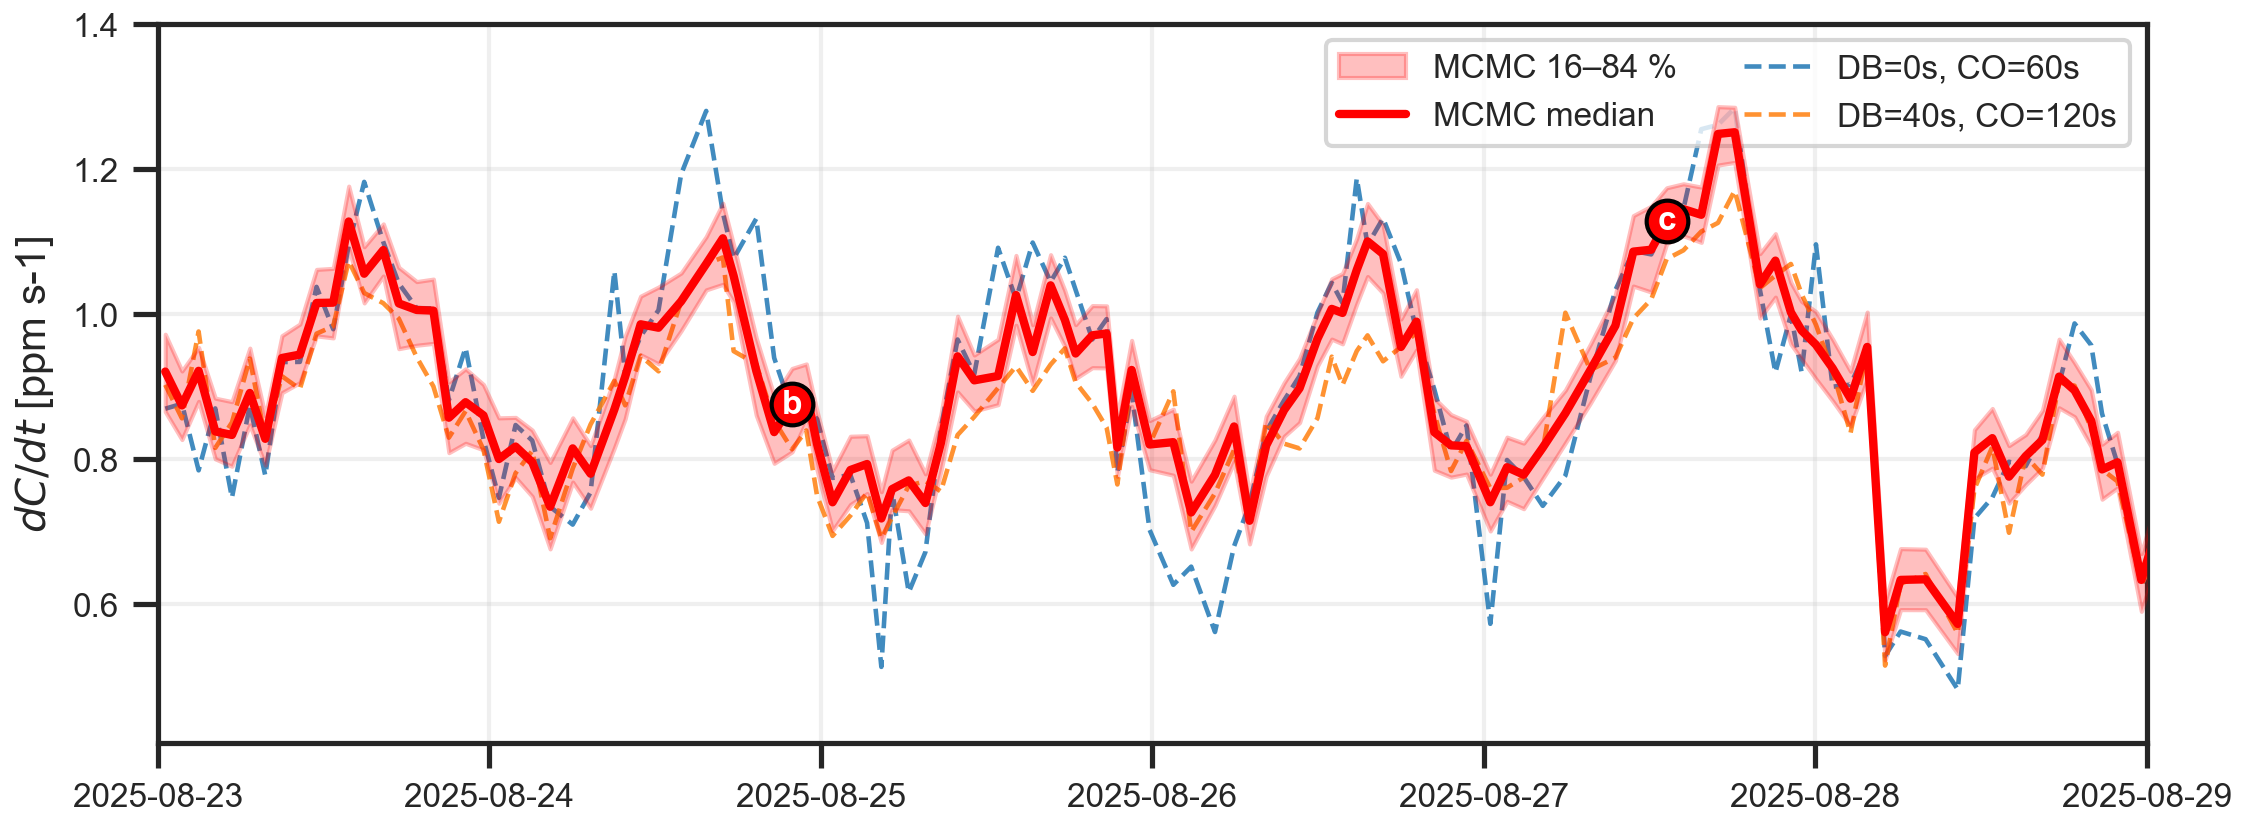

In [50]:
# ── Plot 9: walk-filter — only a hand-picked list of (deadband, cutoff) ─────
#
# Same walk-filter logic as Plot 8, but instead of plotting every
# (cutoff, deadband) combination from the simple grid we only plot the pairs
# listed in `selected_combinations` below. Each entry is (deadband, cutoff).

# (deadband [s], cutoff [s]) pairs to overlay on top of the MCMC band.
selected_combinations = [
    (0, 60),
    # (20, 90),
    (40, 120),
]

min_gap = pd.Timedelta('45min')
max_gap = pd.Timedelta('55min')
restart_on_large_gap = True

# Crop window (independent of the other plots; defaults to Section 5's).
plot9_start = plot_start
plot9_end   = plot_end

overlay_alpha = 0.85
overlay_lw    = 1.1


if run_type != 'mcmc_pareto' or ds is None:
    print("Section 9 requires run_type='mcmc_pareto' — skipping.")
else:
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files found in {data_path} for the comparison overlay."
        )
    ds_simple = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time',
    ).sortby('time')
    if date_start:
        ds_simple = ds_simple.sel(time=slice(date_start, date_end))
    ds_simple = ds_simple.sel(time=slice(plot9_start, plot9_end))

    # ── Sanitise + crop the MCMC summary ──────────────────────────────────
    s_idx = pd.DatetimeIndex(summary.index)
    med   = np.asarray(summary['dcdt_median'], dtype=float)
    q16   = np.asarray(summary['dcdt_q16'],    dtype=float)
    q84   = np.asarray(summary['dcdt_q84'],    dtype=float)
    good  = (~s_idx.isna()
             & np.isfinite(med) & np.isfinite(q16) & np.isfinite(q84))
    s_idx, med, q16, q84 = s_idx[good], med[good], q16[good], q84[good]
    crop_mask = np.ones(len(s_idx), dtype=bool)
    if plot9_start is not None:
        crop_mask &= s_idx >= pd.Timestamp(plot9_start)
    if plot9_end is not None:
        crop_mask &= s_idx <= pd.Timestamp(plot9_end)
    s_idx, med, q16, q84 = s_idx[crop_mask], med[crop_mask], q16[crop_mask], q84[crop_mask]

    # Walk-filter the MCMC index.
    mcmc_keep = _walk_mask(s_idx, min_gap, max_gap, restart_on_large_gap)
    s_idx, med, q16, q84 = s_idx[mcmc_keep], med[mcmc_keep], q16[mcmc_keep], q84[mcmc_keep]
    print(f"MCMC summary:   {mcmc_keep.sum()} / {len(mcmc_keep)} kept "
          f"(min_gap={min_gap}, max_gap={max_gap}, restart={restart_on_large_gap})")

    if len(s_idx) == 0:
        raise ValueError(
            "No MCMC points left after walk filter — widen [min_gap, max_gap]."
        )

    # Sync the simple dataset to the same kept timestamps.
    sel_times = xr.DataArray(s_idx.values, dims='time')
    ds_simple_kept = ds_simple.reindex(time=sel_times, method='nearest',
                                       tolerance=pd.Timedelta('1min'))
    n_matched = int(ds_simple_kept['time'].notnull().sum())
    print(f"Simple dataset: matched {n_matched} / {len(s_idx)} MCMC timestamps "
          f"(±1 min tolerance)")

    # Validate the requested combinations against the simple grid.
    avail_cutoffs   = set(np.atleast_1d(ds_simple_kept['cutoff'].values).tolist())
    avail_deadbands = set(np.atleast_1d(ds_simple_kept['deadband'].values).tolist())
    valid_pairs = []
    for (d, c) in selected_combinations:
        if c not in avail_cutoffs or d not in avail_deadbands:
            print(f"  ⚠  (deadband={d}, cutoff={c}) not in simple grid — skipping.")
            continue
        valid_pairs.append((d, c))
    print(f"Plotting {len(valid_pairs)} of {len(selected_combinations)} requested pairs.")

    da_grid = ds_simple_kept['dcdt(HM)']
    if 'MC' in da_grid.dims:
        da_grid = da_grid.median(dim='MC')

    fig, axes = plt.subplots(
        1, 1, figsize=(19*cm, 7*cm), dpi=300, sharex=True,
        # gridspec_kw={'height_ratios': [3, 1, 1]},
        constrained_layout=True,
    )

    ax = axes
    ax.fill_between(s_idx, q16, q84, color='red', alpha=0.25,
                    label='MCMC 16–84 %', zorder=20)
    ax.plot(s_idx, med, color='red', lw=2.0,  ms=3,
            label='MCMC median', zorder=20)
    
    ax.scatter(s_idx[36], med[36], color='red', s=100, zorder=25, edgecolors='black', linewidths=1)
    ax.text(s_idx[36], med[36], 'b', color='white', fontsize=8, fontweight='bold',
            zorder=25, ha='center', va='center')
    
    ax.scatter(s_idx[88], med[88], color='red', s=100, zorder=25, edgecolors='black', linewidths=1)
    ax.text(s_idx[88], med[88], 'c', color='white', fontsize=8, fontweight='bold',
            zorder=25, ha='center', va='center')
    
    

    overlay_colors = plt.get_cmap('tab10')
    simple_time_kept = ds_simple_kept['time'].values

    for k, (d, c) in enumerate(valid_pairs):
        flux_raw = da_grid.sel(cutoff=c, deadband=d).values
        ts, flux = _clean_series(simple_time_kept, flux_raw)
        if len(ts) == 0:
            print(f"  ⚠  (deadband={d}, cutoff={c}) — all values non-finite, skipping.")
            continue
        ax.plot(ts, flux,
                color=overlay_colors(k % 10),
                lw=overlay_lw, alpha=overlay_alpha, linestyle='--',
                ms=4, zorder=3,
                label=f'DB={d}s, CO={c}s')

    q_lo, q_hi = float(np.min(q16)), float(np.max(q84))
    pad = 0.15 * (q_hi - q_lo if q_hi > q_lo else max(abs(q_hi), 1.0))
    ax.set_ylim(q_lo - pad, q_hi + pad)

    title_window = f"{plot9_start or '…'}  →  {plot9_end or '…'}"
    ax.set_ylabel('$dC/dt$ [ppm s-1]', fontsize=10)
    # ax.set_title(
    #     f'Walk-filtered selected (deadband, cutoff) pairs  '
    #     f'(gap ∈ [{min_gap}, {max_gap}])  —  {data_path.name}  [{title_window}]'
    # )
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(alpha=0.3)


    if plot9_start is not None or plot9_end is not None:
        x_lo = pd.Timestamp(plot9_start) if plot9_start is not None else s_idx.min()
        x_hi = pd.Timestamp(plot9_end)   if plot9_end   is not None else s_idx.max()
        # axes[0].set_xlim(x_lo, x_hi)
        ax.set_xlim(x_lo, x_hi)

    # for label in axes[2].get_xticklabels():
    #     label.set_rotation(30)
    #     label.set_ha('right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    ax.set_xlim(dt.datetime(2025,8,23), dt.datetime(2025,8,29))

    if fig_output_dir:
        pathlib.Path(fig_output_dir).mkdir(parents=True, exist_ok=True)
        fig.savefig(
            pathlib.Path(fig_output_dir) / 'mcmc_vs_selected_combinations_walk.png',
            dpi=fig_dpi,
        )

    plt.show()


In [ ]:
import ipywidgets as widgets

## Section 8b — Interactive Pareto browser

Scroll through every closure in `summary` using an `ipywidgets` slider —
each tick renders that measurement's Pareto front with the same cell-7
styling and `(deadband, cutoff)` annotations as Section 8.

Knobs (`pareto_browser_*`) at the top of the cell control which subset
of `summary` is exposed to the slider (date range, stride). The slider
itself is the only interaction needed afterwards.

Requires the full simple `*.nc` (see Section 8 file requirement) and
`ipywidgets` (already a Jupyter dependency).

In [30]:
import seaborn as sns
color_p = sns.color_palette('coolwarm', n_colors=2)
color_p[0] = 'red'

In [44]:
# ── Interactive Pareto browser (scroll through measurements) ─────────────
# Left subplot: Pareto front (normalized or raw, toggled via flag).
# Right subplot: raw CO₂ closure curve for the selected measurement, with the
# best (deadband, cutoff) window shaded. The summary-stored window is shaded
# too if it differs from the recomputed best.

from soilgasflux_fcs.pareto import Pareto
from soilgasflux_fcs.json_reader import Initializer
from ipywidgets import interact, IntSlider, Checkbox
from IPython.display import display

# ── Browser filters ──────────────────────────────────────────────────────
pareto_browser_stride     = 1       # keep every Nth row of summary
pareto_browser_date_range = None    # ('2026-04-05', '2026-04-07') or None
use_normalized_axes       = False
pareto_match_tol          = pd.Timedelta('5min')

# ── Raw closure folder for the right subplot ────────────────────────────
pareto_browser_raw_path = pathlib.Path(
    '/Users/alexnaokiasatokobayashi/Documents/data/Gals/gals_20250829/sgf_07_pt02/data'
)
pareto_browser_raw_tol  = pd.Timedelta('5min')   # closure ↔ summary-time tol


# ── Load ds_simple if not already in scope ──────────────────────────────
if 'ds_simple' not in globals() or ds_simple is None:
    simple_files = sorted(
        f for f in data_path.glob(simple_file_pattern) if 'bestPareto' not in f.name
    )
    if not simple_files:
        raise FileNotFoundError(
            f"No simple .nc files match {simple_file_pattern} in {data_path}"
        )
    ds_simple_local = xr.concat(
        [xr.open_dataset(f) for f in simple_files], dim='time'
    ).sortby('time')
else:
    ds_simple_local = ds_simple

if 'MC' not in ds_simple_local.dims:
    raise ValueError(
        "ds_simple has no 'MC' dim. The Pareto front needs the FULL simple "
        ".nc files (dims: time × cutoff × deadband × MC). The *_bestPareto.nc "
        "variants only carry the chosen point per timestamp and cannot be used "
        "here — check simple_file_pattern in the Configuration cell."
    )

# ── Load raw closures (once) ────────────────────────────────────────────
if not pareto_browser_raw_path.exists():
    raise FileNotFoundError(
        f"pareto_browser_raw_path does not exist: {pareto_browser_raw_path}"
    )
_pb_init = Initializer(pareto_browser_raw_path)
_pb_df_raw = _pb_init.prepare_rawdata()
_pb_starts = (_pb_df_raw.groupby('id')['datetime'].min()
                       .rename('start').sort_values())
_pb_starts_idx = pd.DatetimeIndex(_pb_starts.values)
_pb_df_raw_by_id = {gid: g.sort_values('datetime')
                    for gid, g in _pb_df_raw.groupby('id')}
print(f"Loaded {len(_pb_starts)} raw closures from {pareto_browser_raw_path.name}")

# ── Build the slider's measurement list ─────────────────────────────────
browser_summary = summary
if pareto_browser_date_range is not None:
    s, e = pareto_browser_date_range
    browser_summary = browser_summary.loc[s:e]
browser_summary = browser_summary.iloc[::pareto_browser_stride]
print(f"Slider covers {len(browser_summary)} measurement(s)  "
      f"(stride={pareto_browser_stride}, date_range={pareto_browser_date_range})")

if len(browser_summary) == 0:
    raise ValueError("No measurements left after filters — adjust pareto_browser_* "
                     "or run the upstream cells.")

ds_times = pd.DatetimeIndex(ds_simple_local['time'].values)


def _plot_pareto_for_idx(idx, annotate_front, annotate_best_pt,
                         show_pareto_windows):
    ts  = browser_summary.index[idx]
    row = browser_summary.iloc[idx]
    requested = pd.Timestamp(ts)

    pos = ds_times.get_indexer([requested], method='nearest',
                               tolerance=pareto_match_tol)[0]
    if pos < 0:
        print(f"No ds_simple time within ±{pareto_match_tol} of {requested}.")
        return

    ds_t = ds_simple_local.isel(time=pos)
    matched_time = pd.Timestamp(ds_t['time'].values)

    try:
        pa = Pareto(dsMC=ds_t)
        Norm_u, Norm_l, flat_u, flat_l = pa.prepare_metrics()
        pareto_idx = pa.find_pareto_front(x=flat_u, y=flat_l,
                                          maximize_x=False, maximize_y=False)
        if len(pareto_idx) == 0:
            print(f"Empty Pareto front at {matched_time}.")
            return
        coords_pf = pa.get_coords_pareto(pareto_indices=pareto_idx)
        best_x, best_y = pa.get_best_from_pareto(
            pareto_indices=pareto_idx,
            metric_x=Norm_u, metric_y=Norm_l,
        )
    except Exception as ex:
        print(f"Pareto failed at {matched_time}: {ex}")
        return

    if use_normalized_axes:
        u_all, l_all = flat_u, flat_l
        u_pf,  l_pf  = Norm_u[coords_pf], Norm_l[coords_pf]
        u_best, l_best = Norm_u[best_x, best_y], Norm_l[best_x, best_y]
        xlabel, ylabel = 'Uncertainty Range', 'Log Probability'
    else:
        u_raw, l_raw = pa.uncertaintyRange.values, pa.logprob.values
        u_all, l_all = u_raw.flatten(), l_raw.flatten()
        u_pf,  l_pf  = u_raw[coords_pf], l_raw[coords_pf]
        u_best, l_best = u_raw[best_x, best_y], l_raw[best_x, best_y]
        xlabel = 'Uncertainty Range'
        ylabel = 'Log Probability'

    cutoff_coords   = pa.cutoff_cords
    deadband_coords = pa.deadband_coords
    pf_cutoffs   = cutoff_coords[coords_pf[0]]
    pf_deadbands = deadband_coords[coords_pf[1]]
    recomputed_d = int(deadband_coords[best_y])
    recomputed_c = int(cutoff_coords[best_x])

    fig, (ax, ax_raw) = plt.subplots(1, 2, figsize=(9* cm, 4.5 * cm), dpi=300)

    # ── Left: Pareto front ────────────────────────────────────────────
    ax.scatter(u_all, l_all, s=10, c=color_p[0], alpha=0.2,
               label='all (cutoff, deadband)')
    ax.scatter(u_pf,  l_pf,  s=20, c=color_p[0],  alpha=0.9,
               linewidth=0.3, edgecolor='k',
               label='Pareto front')
    ax.scatter([u_best], [l_best], s=80, c=color_p[0], alpha=0.9,marker='*',                               
               linewidth=0.5, edgecolor='k',
               zorder=10, label='best (recomputed)')
    if use_normalized_axes:
        ax.plot([0, u_best], [0, l_best], c=color_p[0], alpha=0.5, lw=0.8)

    if annotate_front:
        for x, y, d, c in zip(u_pf, l_pf, pf_deadbands, pf_cutoffs):
            ax.annotate(f'({int(d)},{int(c)})',
                        xy=(x, y), xytext=(3, 3),
                        textcoords='offset points',
                        fontsize=6, color='darkred', alpha=0.8)
    if annotate_best_pt:
        ax.annotate(f'CO: {recomputed_c}\n DB: {recomputed_d}',
                    xy=(u_best, l_best), xytext=(u_best+u_best*0.3, l_best+l_best*0.3),
                    # textcoords='offset points',
                    fontsize=7, 
                    # color='blue', weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", 
                              facecolor=color_p[0], 
                              alpha=0.2,
                              edgecolor=color_p[0]),
                    arrowprops=dict(arrowstyle='->', 
                                     connectionstyle="arc3,rad=0.1",
                                     color='grey',
                                     lw=1), zorder=15)

    stored = None
    try:
        stored_d = int(row['best_deadband'])
        stored_c = int(row['best_cutoff'])
        cutoffs   = cutoff_coords.tolist()
        deadbands = deadband_coords.tolist()
        if stored_c in cutoffs and stored_d in deadbands:
            ix = cutoffs.index(stored_c)
            iy = deadbands.index(stored_d)
            if use_normalized_axes:
                u_st, l_st = Norm_u[ix, iy], Norm_l[ix, iy]
            else:
                u_st = pa.uncertaintyRange.values[ix, iy]
                l_st = pa.logprob.values[ix, iy]
            # ax.scatter([u_st], [l_st], s=60, marker='s',
            #            facecolor='none', edgecolor='blue',
            #            linewidth=1.0, alpha=0.9, zorder=11,
            #            label=f'summary best ({stored_d}, {stored_c})')
            stored = (stored_d, stored_c)
            if stored != (recomputed_d, recomputed_c):
                ax.annotate(f'summary  ({stored_d}, {stored_c})',
                            xy=(u_st, l_st), xytext=(8, -12),
                            textcoords='offset points',
                            fontsize=7, color='blue', alpha=0.8,
                            arrowprops=dict(arrowstyle='-', color='blue',
                                            alpha=0.5, lw=0.6))
    except Exception:
        pass

    ax.set_title(f'Pareto  —  [{idx + 1}/{len(browser_summary)}]  {matched_time}',
                 fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=7)
    # ax.legend(fontsize=6, loc='best', framealpha=0.85)
    # ax.grid(alpha=0.3)

    # ── Right: raw CO₂ closure curve ──────────────────────────────────
    raw_pos = _pb_starts_idx.get_indexer([requested], method='nearest',
                                         tolerance=pareto_browser_raw_tol)[0]
    if raw_pos < 0:
        ax_raw.text(0.5, 0.5,
                    f'No raw closure within ±{pareto_browser_raw_tol}\nof {requested}',
                    ha='center', va='center', transform=ax_raw.transAxes,
                    fontsize=8, color='gray')
        ax_raw.set_xticks([]); ax_raw.set_yticks([])
    else:
        raw_id = _pb_starts.index[raw_pos]
        raw_df = _pb_df_raw_by_id.get(raw_id)
        if raw_df is None or len(raw_df) == 0:
            ax_raw.text(0.5, 0.5, f'Empty raw closure for id={raw_id}',
                        ha='center', va='center', transform=ax_raw.transAxes,
                        fontsize=8, color='gray')
        else:
            t = raw_df['timedelta'].values
            y = raw_df['k30_co2'].values
            ax_raw.plot(t, y, lw=0.8, c='gray', alpha=0.9,
                        label=f'closure  id={raw_id}')

            t_min, t_max = float(np.nanmin(t)), float(np.nanmax(t))

            # Optionally overlay every Pareto-front (deadband, cutoff) window
            if show_pareto_windows and len(pf_deadbands) > 0:
                for k, (d_k, c_k) in enumerate(zip(pf_deadbands, pf_cutoffs)):
                    lo = max(t_min, float(d_k))
                    hi = min(t_max, float(c_k))
                    if hi <= lo:
                        continue
                    is_first = (k == 0)
                    ax_raw.axvspan(lo, hi, facecolor=color_p[0], edgecolor='none',
                                   alpha=0.05,
                                   label='Pareto windows' if is_first else None)

            # Shade the recomputed best (deadband, cutoff) window
            d_lo = max(t_min, float(recomputed_d))
            d_hi = min(t_max, float(recomputed_c))
            if d_hi > d_lo:
                ax_raw.axvspan(d_lo, d_hi, color=color_p[0], alpha=0.3, hatch='*',zorder=0,
                               label=f'best window  ({recomputed_d}, {recomputed_c})')
            # Overlay summary-stored window if different
            if stored is not None and stored != (recomputed_d, recomputed_c):
                s_lo = max(t_min, float(stored[0]))
                s_hi = min(t_max, float(stored[1]))
                # if s_hi > s_lo:
                #     ax_raw.axvspan(s_lo, s_hi, facecolor='none',
                #                    edgecolor='blue', linewidth=1.0,
                #                    linestyle='--', alpha=0.9,
                #                    label=f'summary window  ({stored[0]}, {stored[1]})')

            raw_start = pd.Timestamp(_pb_starts.iloc[raw_pos])
            # ax_raw.set_title(f'Raw $CO_2$  —  closure start {raw_start}', fontsize=9)
            ax_raw.set_xlabel('Time [s]', fontsize=8)
            ax_raw.set_ylabel('$CO_2$  [ppm]', fontsize=8)
            ax_raw.tick_params(labelsize=7)
            # ax_raw.legend(fontsize=6, loc='best', framealpha=0.85)
            ax_raw.grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


# ── Wire up the slider ───────────────────────────────────────────────────
slider = IntSlider(
    min=0, max=len(browser_summary) - 1, step=1, value=0,
    description='measurement',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout={'width': '75%'},
)
chk_front          = Checkbox(value=True,  description='annotate Pareto front')
chk_best           = Checkbox(value=True,  description='annotate best point')
chk_pareto_windows = Checkbox(value=False, description='show Pareto windows on raw')

interact(_plot_pareto_for_idx,
         idx=slider,
         annotate_front=chk_front,
         annotate_best_pt=chk_best,
         show_pareto_windows=chk_pareto_windows)


Loaded 832 raw closures from data
Slider covers 267 measurement(s)  (stride=1, date_range=None)


interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement', layout=Layout(wid…

<function __main__._plot_pareto_for_idx(idx, annotate_front, annotate_best_pt, show_pareto_windows)>